# USES CALC V3 and MC V4 AND NEW REBOUND

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from src.simulations.Rebound_v4 import OrbitalSimulation
from numpy.random import SeedSequence, Generator, PCG64
import src.utils.calculations_v3 as calc
import multiprocessing
import datetime
from numpy.random import SeedSequence, Generator, PCG64
import src.simulations.MonteCarlo_impsamp_v4 as MCi
import src.configurations.Configuration as conf
import src.analysis.Analysis_v2 as anl
import src.plotting.Plotting_v2 as pl
import datetime as dt
import os
from astropy.cosmology import FlatLambdaCDM


Using REPO_ROOT: /data/a.saricaoglu/repo/captus


# Simulation Runs

In [2]:
mPBH_grid = np.logspace(np.log10(1e-3), np.log10(10), 5) * const.M_sun.value  # from 1e-10 to 1 solar mass
print(mPBH_grid)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
H = cosmo.H(0).to(u.yr**-1).value  # Hubble constant in 1/yr
print(f"Hubble time: {1/H:.2e} yr")

[1.98840987e+27 1.98840987e+28 1.98840987e+29 1.98840987e+30
 1.98840987e+31]
Hubble time: 1.40e+10 yr


In [3]:
run_dict = {}
for i, mPBH in enumerate(mPBH_grid):

    seed = i + 100  # Just a way to get different seeds
    name = f"OmegaCenturiBH_MS_s{seed}_calcv3_MCv4_reboundV4"
    configuration = conf.Configuration(name=name, seed=seed, importance_sampling=True)
    configuration.set_system_param('mC', mPBH)  # Mass of light PBH
    configuration.set_simulation_param('sample_size', 500)  # Mass of light PBH
    configuration.set_simulation_param('max_trials', 1000000000)  # Mass of light PBH
    max_v_default = configuration.get_simulation_param(all=True)['v_inf_grid'][-1]
    configuration.set_simulation_param('max_v', 0.75 * max_v_default)
    configuration.print_configuration()
    run_dict[name] = {'name': name, 'seed': seed, 'configuration': configuration}
    print(f"Prepared configuration for mPBH = {mPBH / const.M_sun.value} solar masses.\n")


Updated system parameter 'mC' to 1.988409870698051e+27 and recalculated rC.
Updated v_inf_grid_params 'max_v' to 254539.28999999998 and regenerated v_inf_grid.
System Parameters:
  mA: 1.6304960939724018e+34
  mB: 1.988409870698051e+31
  mC: 1.988409870698051e+27
  aB: 92562705350480.95
  rA: 24216650.624022048
  rB: 3478500000.0
  vB: 110000.0
  eB: 0.2
  iB: 0
  epsilon: 0.05947540101248887
  seed_base: 100
  name: OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4
  rC: 2.95325007610025

Simulation Parameters:
  trials: 10000000
  max_trials: 1000000000
  max_execution_time: 3600
  sample_size: 500
  max_e: 1.0
  vDM: 220000.0
  v_inf_grid_params: {'min_v': 1000, 'max_v': np.float64(254539.28999999998), 'n_v': 10}
  importance_sampling: True
  v_inf_grid: [  1000.          29171.03222222  57342.06444444  85513.09666667
 113684.12888889 141855.16111111 170026.19333333 198197.22555556
 226368.25777778 254539.29      ]
Prepared configuration for mPBH = 0.001 solar masses.

Updated system par

In [18]:
def mc_worker(pars):
    conf, child_ss, v_inf = pars
    rng = Generator(PCG64(child_ss)) # independent per worker
    simulation = MCi.MonteCarloSimulation(conf, rng)
    return simulation.run_monte_carlo_simulation(v_inf)

if __name__ == "__main__":
    all_pars = []
    start_time = datetime.datetime.now()
    
    for run in run_dict.values():
        print(f"Preparing simulation: {run['name']}")
        configuration_ = run['configuration']
        seed_ = run['seed']
        v_inf_grid_ = configuration_.get_simulation_param('v_inf_grid')
        base_ss = SeedSequence(seed_)
        print(f'  {len(v_inf_grid_)} v_inf values: {v_inf_grid_[0]:.1f} to {v_inf_grid_[-1]:.1f} m/s')
        child_sss = base_ss.spawn(len(v_inf_grid_))
        pars = [(configuration_, child_sss[i], v_inf_grid_[i]) for i in range(len(v_inf_grid_))]
        all_pars.extend(pars)
    
    num_cores = 50
    print(f'\n{"="*60}')
    print(f'Total simulations to run: {len(all_pars)}')
    print(f'Configurations: {len(run_dict)}')
    print(f'CPU cores: {num_cores}')
    print(f'{"="*60}\n')
    
    with multiprocessing.Pool(processes=num_cores) as pool:
        results = pool.map(mc_worker, all_pars)
    
    elapsed_time = datetime.datetime.now() - start_time
    print(f'\n{"="*60}')
    print(f'✓ All simulations complete!')
    print(f'Total time: {elapsed_time} ({elapsed_time.total_seconds()/60:.2f} minutes)')
    print(f'Completed {len(all_pars)} simulations across {len(run_dict)} configurations')
    print(f'{"="*60}')

Preparing simulation: OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s101_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s102_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s103_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s104_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s

Total simulations to run: 50
Configurations: 5
CPU cores: 50



for v_inf=198.19722555555555 km/s and mC 0.1 M_sun MC capture cross-section:for v_inf=170.02619333333334 km/s and mC 0.01 M_sun MC capture cross-section:  2.6364728284231835e+252.6161596167928557e+25  m^2m^2

for v_inf=170.02619333333334 km/s and mC 0.01 M_sun MC capture cross-section (dσ avg):for v_inf=198.19722555555555 km/s and mC 0.1 M_sun MC capture cross-section (dσ avg):  1.2529018334633701 AU2 0.5035206365443389 AU2au^2 
au^2Number of captured orbits: 500, e condition met: 546, out of 564 samples.

Number of captured orbits: 500, e condition met: 547, out of 563 samples.for v_inf=226.36825777777776 km/s and mC 0.1 M_sun MC capture cross-section:
 2.627140181242925e+25 m^2
for v_inf=226.36825777777776 km/s and mC 0.1 M_sun MC capture cross-section (dσ avg): 0.19802535650552947 AU2 au^2for v_inf=141.8551611111111 km/s and mC 0.1 M_sun MC capture cross-section:
Number of captured orbits: 500, e condition met: 551, out of 565 samples. 2.645872018542339e+25
Results saved for v_inf=1

In [19]:
for run in run_dict.values():

    configuration = run['configuration']
    name = run['name']
    analysis = anl.Analysis(name=configuration.name, configuration=configuration)
    mc = analysis.get_mc_results()
    sampled_mc = analysis.get_sampled_mc_results()
    run_dict[name]['sampled_mc'] = sampled_mc
    # Debug: Check MC data structure and read inclinations

        

    

Loading MC results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Rebound_Simulation_Results/
captured objects for v_inf = V1 km/s: 500
v_inf = V1 km/s: sampled 500 captured objects
captured objects for v_inf = V29 km/s: 500
v_inf = V29 km/s: sampled 500 captured objects
captured objects for v_inf = V57 km/s: 500
v_inf = V57 km/s: sampled 500 captured objects
captured objects for v_inf = V86 km/s: 500
v_inf = V86 km/s: sampled 500 captured objects
captured objects for v_inf = V114 km/s: 500
v_inf = V114 km/s: sampled 500 captured objects
captured objects for v_inf = V142 km/s: 500
v_inf = V142 km/s: sampled 500 captured objects
captured objects for v_inf = V170 km/s: 500
v_inf = V170 km/s: sampled 500 captured objects
captured objects for v_inf = V198 km/s: 500
v_inf = V198 km/s: sampled 500 captured objects
captured

In [20]:
import rebound
def check_rebound_trajectories(mA, mB, mC, pos_C, v_C, pos_B, v_B ):
        mA = (mA*u.kg).to(u.Msun).value
        mB = (mB*u.kg).to(u.Msun).value
        mC = (mC*u.kg).to(u.Msun).value
        rA = calc.schwarzchild_radius(mA)
        pos_C = (np.array(pos_C) * u.m).to(u.au).value
        v_C = (np.array(v_C) * u.m/u.s).to(u.au/u.yr).value
        pos_B = (np.array(pos_B) * u.m).to(u.au).value
        v_B = (np.array(v_B) * u.m/u.s).to(u.au/u.yr).value
        # Gravitational parameter in these units: G = 4*pi^2 AU^3/(Msun*yr^2)
        sim = rebound.Simulation()
        sim.units = ('AU', 'yr', 'Msun')
        sim.integrator = "MERCURIUS"
        sim.add(m=mA, r=rA)  # Sun
        sim.add(m=mB, x=pos_B[0], y=pos_B[1], z=pos_B[2], vx=v_B[0], vy=v_B[1], vz=v_B[2])  # Jupiter
        sim.add(m=mC, x=pos_C[0], y=pos_C[1], z=pos_C[2], vx=v_C[0], vy=v_C[1], vz=v_C[2])  # PBH

        G_unit = sim.G  # 4*pi^2 in these units
        sim.move_to_com()

        a_init = sim.particles[2].orbit(primary=sim.particles[0]).a
        e_init = sim.particles[2].orbit(primary=sim.particles[0]).e
        Evc = 0.5 * (sim.particles[2].vx**2 + sim.particles[2].vy**2 + sim.particles[2].vz**2)
        rAC = np.abs(sim.particles[2] ** sim.particles[0])
        E_c_cond = Evc - (G_unit*(sim.particles[0].m + sim.particles[2].m) / rAC)
        ec = (E_c_cond < 0)
        captured =  ec & (e_init < 1) & (a_init > 0)
        if captured:
            c= 'green'
        elif ec:
            c= 'blue'
        else:
            c= 'red'

        return E_c_cond, a_init, e_init, c
        

        
# Visualize initial conditions from actual sampled_mc data
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import src.utils.calculations_v3 as calc
%matplotlib widget

# Get data from sampled_mc (already loaded)
for run in run_dict.values():
    configuration = run['configuration']
    sampled_mc = run['sampled_mc']
    name = run['name']
    mA = configuration.get_system_param('mA')
    mB = configuration.get_system_param('mB')
    mC = configuration.get_system_param('mC')
    epsilon = configuration.get_system_param('epsilon')  # Softening parameter for r_close calculation
    vBMag = configuration.get_system_param('vB')  # Jupiter velocity magnitude
    muA = calc.standard_gravitational_parameter(mA, mC)
    muB = calc.standard_gravitational_parameter(mB, mC)
    aB = configuration.get_system_param('aB')
    rClose = calc.r_close(epsilon, muA, muB, aB)
    sys_with_failed_capture = {}
    v_keys = list(sampled_mc.keys())
    for m in v_keys:
        sys_with_failed_capture[m] = {}
        v_inf = sampled_mc[m]['v_inf']
        for idx in range(len(sampled_mc[m]['cap_C_pos'])):  # Loop through all captured samples
        # Get the parameters
            pos_C_m = sampled_mc[m]['cap_C_pos'][idx]  # Exit position in meters
            pos_B_m = sampled_mc[m]['cap_B_pos'][idx]  # Jupiter position
            v_C_m_s = sampled_mc[m]['cap_C_v2'][idx]   # v2' in m/s
            v_B_m_s = sampled_mc[m]['cap_B_v'][idx]    # vB in m/s
            # v1prime_m_s = sampled_mc[m]['cap_C_v1prime'][idx]  # v1' in m/s
            v2Mag = np.linalg.norm(v_C_m_s)
            # Sample a population with different exit positions over r close sphere in spherical coordinates (theta, phi) to visualize the hyperbolic trajectories
            exit_positions = []
            for theta in np.linspace(0, 2 * np.pi, 100):
                for phi in np.linspace(0, np.pi, 100):
                    exit_at_rclose = [rClose * np.cos(theta) * np.sin(phi)  , rClose * np.sin(theta) * np.sin(phi),  rClose * np.cos(phi)]
                    exit_positions.append(exit_at_rclose)
            # Calculate energy and angular momentum for each exit position to check the capture condition
            energies = []
            angular_momenta = []
            a_l, e_l= [], []
            exit_pos_A_frame = []
            colors = []
            energies_rebound, a_rebound, e_rebound, colors_rebound = [], [], [], []
            for exit in exit_positions:
                exit_in_A_frame = exit + pos_B_m  # Transform exit position from B frame to A frame
                energy = 0.5 * v2Mag**2 - muA / np.linalg.norm(exit_in_A_frame)
                angular_momentum = calc.specific_L2(exit_in_A_frame, v_C_m_s)
                a, e = calc.a_e(muA, energy, angular_momentum)
                ec = (energy < 0)
                captured =  ec & (e < 1) & (a > 0)
                if captured:
                    c= 'green'
                elif ec:
                    c= 'blue'
                else:
                    c= 'red'
                colors.append(c)
                a_l.append(a)
                e_l.append(e)       
                exit_pos_A_frame.append(exit_in_A_frame)
                # Check with Rebound
                E_rebound, a_rebound_val, e_rebound_val, c_rebound = check_rebound_trajectories(mA, mB, mC, exit_in_A_frame, v_C_m_s, pos_B_m, v_B_m_s)
                energies_rebound.append(E_rebound)
                a_rebound.append(a_rebound_val)
                e_rebound.append(e_rebound_val)
                colors_rebound.append(c_rebound)
            c1 = colors.count('red')
            c2 = colors_rebound.count('red')
            if c1 > 0 or c2 > 0:
                print(f"Red trajectories found for v_inf = {v_inf:.2f} m/s, idx = {idx}, c1 = {c1}, c2 = {c2}")
                sys_with_failed_capture[m][idx] = {
                    'exit_positions': exit_pos_A_frame,
                    'energies': energies,
                    'angular_momenta': angular_momenta,
                    'a_l': a_l,
                    'e_l': e_l,
                    'colors': colors,
                    'energies_rebound': energies_rebound,
                    'a_rebound': a_rebound,
                    'e_rebound': e_rebound,
                    'colors_rebound': colors_rebound
                }
    run_dict[name]['sys_with_failed_capture'] = sys_with_failed_capture


Red trajectories found for v_inf = 1000.00 m/s, idx = 2, c1 = 120, c2 = 0
Red trajectories found for v_inf = 1000.00 m/s, idx = 3, c1 = 1456, c2 = 1268
Red trajectories found for v_inf = 1000.00 m/s, idx = 4, c1 = 8380, c2 = 8192
Red trajectories found for v_inf = 1000.00 m/s, idx = 6, c1 = 1418, c2 = 1248


KeyboardInterrupt: 

In [9]:
plt.close('all')

ValueError: 'c' argument has 2288 elements, which is inconsistent with 'x' and 'y' with size 3.

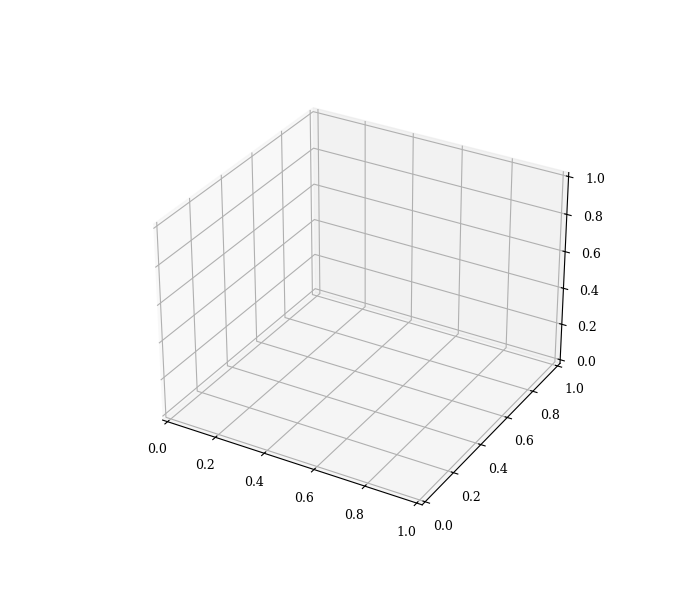

In [22]:
origin = np.array([0,0,0])
exit_pos_A_frame = (np.array(exit_pos_A_frame) * u.m).to(u.au).value  # Ensure it's in AU

# Visualize
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(exit_pos_A_frame[0], exit_pos_A_frame[1], exit_pos_A_frame[2], s=10, color=colors, alpha=0.5)


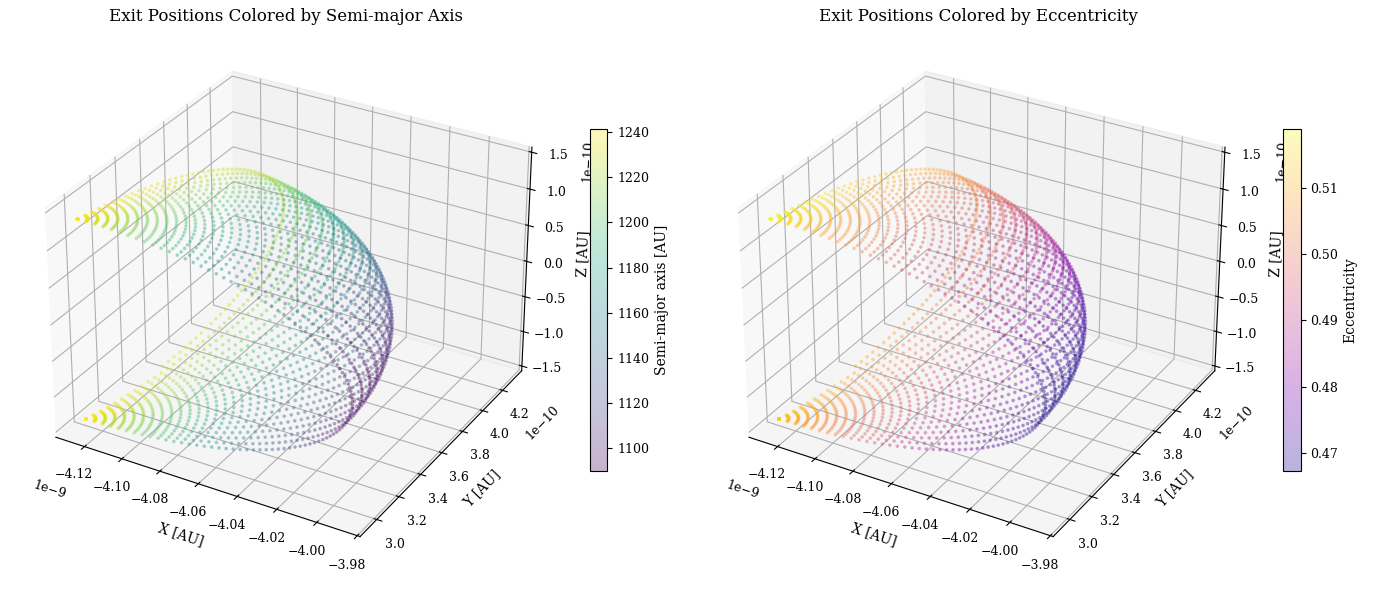

In [23]:
fig = plt.figure(figsize=(14, 6))  # Wider figure for side-by-side plots
ax = fig.add_subplot(121, projection='3d')   # Left subplot (1 row, 2 cols, position 1)
ax2 = fig.add_subplot(122, projection='3d')  # Right subplot (1 row, 2 cols, position 2)

# Convert lists to NumPy arrays
exit_pos_A_frame = (np.array(exit_pos_A_frame) * u.m).to(u.au).value  # Ensure it's in AU
a_l = (np.array(a_l) * u.m).to(u.au).value  # Convert to AU
e_l = np.array(e_l)  # Already dimensionless

# First plot: colored by semi-major axis
scatter1 = ax.scatter(exit_pos_A_frame[:, 0], 
                      exit_pos_A_frame[:, 1], 
                      exit_pos_A_frame[:, 2], 
                      c=a_l, 
                      s=3,
                      alpha=0.3,
                      cmap='viridis',
                      norm=plt.Normalize(vmin=np.min(a_l), vmax=np.max(a_l)))

# Second plot: colored by eccentricity
scatter2 = ax2.scatter(exit_pos_A_frame[:, 0], 
                       exit_pos_A_frame[:, 1], 
                       exit_pos_A_frame[:, 2], 
                       c=e_l, 
                       s=3,
                       alpha=0.3,
                       cmap='plasma',  # Different colormap for distinction
                       norm=plt.Normalize(vmin=np.min(e_l), vmax=np.max(e_l)))

# Add colorbars
fig.colorbar(scatter1, ax=ax, label='Semi-major axis [AU]', shrink=0.6)
fig.colorbar(scatter2, ax=ax2, label='Eccentricity', shrink=0.6)

# Set titles and labels
ax.set_title('Exit Positions Colored by Semi-major Axis')
ax2.set_title('Exit Positions Colored by Eccentricity')

for axis in [ax, ax2]:
    axis.set_xlabel('X [AU]')
    axis.set_ylabel('Y [AU]')
    axis.set_zlabel('Z [AU]')

plt.tight_layout()
plt.show()

In [25]:
# CORRECTED VERSION - Option 2: Process all runs together (more efficient)
def check_result_exists_v2(configuration, v_inf_kms, i, seed):
    """Check if a result file already exists"""
    v_str = f"{v_inf_kms:.0f}"
    save_dir = configuration.get_save_dir_rebound()
    dir_npz = os.path.join(save_dir, f"v{v_str}")
    out_npz = os.path.join(dir_npz, f"sim_{i}_{seed}.npz")
    return os.path.isfile(out_npz)
    # return False
def rebound_worker_v2(pars):
    configuration, child_ss, i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B= pars
    rng = Generator(PCG64(child_ss))
    simulation = OrbitalSimulation(configuration=configuration, rng=rng)
    return simulation.run_orbital_integration(i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B)

if __name__ == "__main__":
    overall_start = datetime.datetime.now()
    num_cores = 50
    
    # Build parameter list for ALL runs together
    all_pars = []
    run_info = []  # Track which parameters belong to which run
    
    for run in run_dict.values():
        print(f"Preparing {run['name']}...")
        conf_ = run['configuration']
        seed_ = run['seed']
        sampled_mc_ = run['sampled_mc']
        
        # Generate seeds for this run
        base_ss = SeedSequence(seed_)
        total_possible = np.sum([len(vdata['idx']) for vdata in sampled_mc_.values()])
        all_child_sss = base_ss.spawn(int(total_possible))
        
        # Build parameters for this run
        run_pars = []
        global_idx = 0
        skipped = 0
        
        for j, (v_key, vdata) in enumerate(sampled_mc_.items()):
            v_inf = vdata['v_inf']
            v_inf_kms = v_inf / 1e3
            lambda1 = vdata['cap_lambda']
            beta = vdata['cap_beta']
            b = vdata['cap_b']
            phi = vdata['cap_phi']
            pos_C = vdata['cap_C_pos']
            v_C = vdata['cap_C_v2']
            pos_B = vdata['cap_B_pos']
            v_B = vdata['cap_B_v']


            for i in vdata['idx']:
                if not check_result_exists_v2(conf_, v_inf_kms, i, seed_):
                    run_pars.append((
                        conf_,
                        all_child_sss[global_idx],
                        i, v_inf, lambda1[i], beta[i], phi[i], b[i],
                        pos_C[i], v_C[i], pos_B[i], v_B[i]
                    ))
                else:
                    skipped += 1
                
                global_idx += 1
        
        all_pars.extend(run_pars)
        run_info.append({
            'name': run['name'],
            'n_sims': len(run_pars),
            'skipped': skipped
        })
        print(f"  Added {len(run_pars)} simulations (skipped {skipped})")
    
    # Run ALL simulations in one pool
    total_to_run = len(all_pars)
    print(f"\n{'='*70}")
    print(f"Running {total_to_run} total simulations across {len(run_dict)} runs")
    print(f"Using {num_cores} cores")
    print(f"{'='*70}\n")
    
    if total_to_run == 0:
        print('✓ All simulations already complete!')
    else:
        with multiprocessing.Pool(processes=min(num_cores, total_to_run)) as pool:
            results = pool.map(rebound_worker_v2, all_pars)
        
        elapsed = datetime.datetime.now() - overall_start
        print(f"\n{'='*70}")
        print(f"✓ ALL RUNS COMPLETE!")
        print(f"Total time: {elapsed} ({elapsed.total_seconds()/60:.2f} min)")
        print(f"Average: {elapsed.total_seconds()/total_to_run:.2f} sec/simulation")
        print(f"{'='*70}")

Preparing OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4...
  Added 5000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s101_calcv3_MCv4_reboundV4...
  Added 5000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s102_calcv3_MCv4_reboundV4...
  Added 5000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s103_calcv3_MCv4_reboundV4...
  Added 5000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s104_calcv3_MCv4_reboundV4...
  Added 5000 simulations (skipped 0)

Running 25000 total simulations across 5 runs
Using 50 cores

Simulation 0 of starting at 2026-02-22 16:43:35.167223
Simulation 125 of starting at 2026-02-22 16:43:35.169271
Simulation 250 of starting at 2026-02-22 16:43:35.171361
Simulation 375 of starting at 2026-02-22 16:43:35.173453
Simulation 0 of starting at 2026-02-22 16:43:35.176494
Simulation 125 of starting at 2026-02-22 16:43:35.178956
Simulation 250 of starting at 2026-02-22 16:43:35.181352
Simulation 375 of starting at 2026-02-22 16:43:35.183723
Simulation

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Error during integration: Particle C is free: E_c:  98.32720761146578, rAC: 1861.053753575923, Simulation failed for system 270, at step 25630. Script continues...
Simulation 271 of starting at 2026-02-22 16:44:20.882268
Error during integration: Particle C is free: E_c:  40.719596510978874, rAC: 981.2138712543696, Simulation failed for system 271, at step 2710. Script continues...
Simulation 272 of starting at 2026-02-22 16:44:20.901783
Error during integration: Particle C is free: E_c:  17.48822297199257, rAC: 1085.7476389017186, Simulation failed for system 272, at step 1860. Script continues...
Simulation 273 of starting at 2026-02-22 16:44:20.916157
Error during integration: Particle C is free: E_c:  61.9221693519616, rAC: 734.8461488789272, Simulation failed for system 276, at step 511420. Script continues...
Simulation 277 of starting at 2026-02-22 16:44:20.974115
Simulation 271  completed at 2026-02-22 16:44:21.035602
Simulation 272 of starting at 2026-02-22 16:44:21.053044
Err

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Simulation 295 of starting at 2026-02-22 16:45:10.885411
Error during integration: Particle C is free: E_c:  3172.1943412003397, rAC: 83.27050407650802, Simulation failed for system 67, at step 2320. Script continues...
Simulation 68 of starting at 2026-02-22 16:45:11.023090
Error during integration: Particle C is free: E_c:  4.028679070485396, rAC: 667.7341481421214, Simulation failed for system 279, at step 30780. Script continues...
Simulation 280 of starting at 2026-02-22 16:45:11.036793
Simulation 20  completed at 2026-02-22 16:45:11.122809
Simulation 21 of starting at 2026-02-22 16:45:11.139114
Error during integration: Particle C is free: E_c:  7.00188266297971, rAC: 1006.8447144665563, Simulation failed for system 295, at step 85750. Script continues...
Simulation 296 of starting at 2026-02-22 16:45:11.321703
Error during integration: Particle C is free: E_c:  7.944191916932027, rAC: 445.63938593116524, Simulation failed for system 43, at step 320920. Script continues...
Simula

...

Simulation 73  completed at 2026-02-23 05:26:21.332027
Simulation 74 of starting at 2026-02-23 05:26:21.783834
Simulation 413  completed at 2026-02-23 05:27:29.881806
Simulation 414 of starting at 2026-02-23 05:27:29.992769
Simulation 74  completed at 2026-02-23 05:27:46.955099
Simulation 75 of starting at 2026-02-23 05:27:47.012767
Simulation 12  completed at 2026-02-23 05:27:54.178559
Simulation 13 of starting at 2026-02-23 05:27:54.558532
Error during integration: Particle C is free: E_c:  2.6404128220621317, rAC: 1360.1561227628688, Simulation failed for system 13, at step 79700. Script continues...
Simulation 14 of starting at 2026-02-23 05:27:55.361061
Simulation 285  completed at 2026-02-23 05:28:11.793881
Simulation 286 of starting at 2026-02-23 05:28:11.922209
Error during integration: Particle C is free: E_c:  9.86906660463228, rAC: 1811.8536653377855, Simulation failed for system 286, at step 6210. Script continues...
Simulation 287 of starting at 2026-02-23 05:28:12.001877


/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Simulation 436  completed at 2026-02-23 10:42:11.250592
Simulation 437 of starting at 2026-02-23 10:42:11.327541
Simulation 196  completed at 2026-02-23 10:42:30.889749
Simulation 197 of starting at 2026-02-23 10:42:30.939382
Simulation 356  completed at 2026-02-23 10:43:19.057402
Simulation 357 of starting at 2026-02-23 10:43:19.167062
Simulation 57  completed at 2026-02-23 10:43:32.205040
Simulation 58 of starting at 2026-02-23 10:43:32.292478
Error during integration: Particle C is free: E_c:  1.7551997067469358, rAC: 1523.1427975268323, Simulation failed for system 58, at step 82330. Script continues...
Simulation 59 of starting at 2026-02-23 10:43:32.629437
Simulation 357  completed at 2026-02-23 10:43:52.136910
Simulation 358 of starting at 2026-02-23 10:43:52.180857
Simulation 53  completed at 2026-02-23 10:43:55.765441
Simulation 54 of starting at 2026-02-23 10:43:55.894815
Simulation 197  completed at 2026-02-23 10:44:35.468234
Simulation 198 of starting at 2026-02-23 10:44:35

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Simulation 372  completed at 2026-02-23 18:04:12.352174
Simulation 373 of starting at 2026-02-23 18:04:12.454090
Simulation 113  completed at 2026-02-23 18:04:35.830945
Simulation 114 of starting at 2026-02-23 18:04:36.127969
Error during integration: Particle C is free: E_c:  461.4225166406154, rAC: 521.9370252073363, Simulation failed for system 114, at step 620. Script continues...
Simulation 115 of starting at 2026-02-23 18:04:36.140457
Error during integration: Particle C is free: E_c:  41.198370692987, rAC: 1750.3951659989668, Simulation failed for system 115, at step 2450. Script continues...
Simulation 116 of starting at 2026-02-23 18:04:36.159437
Error during integration: Particle C is free: E_c:  18.65516220815448, rAC: 905.3803010259218, Simulation failed for system 116, at step 1670. Script continues...
Simulation 117 of starting at 2026-02-23 18:04:36.186033
Error during integration: Particle C is free: E_c:  0.6346505060703294, rAC: 390.124512777114, Simulation failed for

In [50]:
runs_dict = {}
for i, run in enumerate(list(run_dict.keys())):
    print(f"{run}:")
    configuration = run_dict[run]['configuration']
    analysis = anl.Analysis(name=configuration.name, configuration=configuration)
    catalog = analysis.get_combined_dictionary()
    sampled_mc = analysis.get_sampled_mc_results()

    runs_dict[f'run_{i+1}'] = {
        'configuration': configuration,
        'analysis': analysis,
        'catalog': catalog,
        'sampled_mc': sampled_mc
    }
    print("...............................")

OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4:
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Rebound_Simulation_Results/
captured objects for v_inf = V1 km/s: 500
v_inf = V1 km/s: sampled 500 captured objects
captured objects for v_inf = V29 km/s: 500
v_inf = V29 km/s: sampled 500 captured objects
captured objects for v_inf = V57 km/s: 500
v_inf = V57 km/s: sampled 500 captured objects
captured objects for v_inf = V86 km/s: 500
v_inf = V86 km/s: sampled 500 captured objects
captured objects for v_inf = V114 km/s: 500
v_inf = V114 km/s: sampled 500 captured objects
captured objects for v_inf = V142 km/s: 500
v_inf = V142 km/s: sampled 500 captured objects
captured objects for v_inf = V170 km/s: 500
v_inf = V170 km/s: sampled 500 captured objects
captured objects for v_inf = V198 km/s: 500
v_inf = V1

In [13]:
for run in list(runs_dict.keys())[4:]:
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    # print(catalog['total_occurrences_gl'])
# Get only velocity keys
    v_keys = [k for k in catalog.keys() if isinstance(k, str) and k.startswith('V')]

    for v in v_keys:
        print(f"Checking {v} for escape_B...")
        rebounddata = analysis.get_combined_dictionary()[v]['rebound']
        escape_c = 0
        completed = 0
        total = 0
        for d in rebounddata:
            # print(f"  Checking termination flag: {d['termination_flag']}")
            flag = d['termination_flag']
            if 'escape_B' in str(flag):
                total += 1
                print(f"Found escape_B in {run} with termination flag: {flag}")
                if 'escape_C' in str(flag):
                    escape_c += 1
                if 'completed' in str(flag):
                    completed += 1
        print(f"Total escape_B: {total}")
        print(f"Total escape_C: {escape_c}")
        print(f"Total completed: {completed}")
    # analysis.print_termination_counts_summary()
    total_time_exc = 0
    total_completed = 0
    # for v in catalog.keys():
    #     if 'v' in v:
    # #         total_time_exc += catalog[v]['termination_counts']['time_exceeded_count']
    # #         total_completed += catalog[v]['termination_counts']['completed_count']
    
    # # # print(f"Total time exceeded: {total_time_exc}")
    #         # print(f'capture cross sections: {catalog[v]["occurrences"]["capture_cross_section_total"]}')
    #         print(f'n sampled: {catalog[v]["occurrences"]["n_sampled"]}')
    #         print(f'average lifetime total: {catalog[v]["occurrences"]["average_lifetime_total"]}')
    # print(f"Total completed: {total_completed}")
    print("...............................")

run_5:
Checking V1 for escape_B...
Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 200 Rebound entries found.
Combining V29: MC data found, 200 Rebound entries found.
Combining V57: MC data found, 200 Rebound entries found.
Combining V86: MC data found, 200 Rebound entries found.
Combining V114: MC data found, 200 Rebound entries found.
Combining V142: MC data found, 200 Rebound entries found.
Combining V170: MC data found, 200 Rebound entries found.
Combining V198: MC data found, 200 Rebound entries found.
Combining V226: MC data found, 200 Rebound entries found.
Combining V255: MC data found, 200 Rebound entries found.
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in ru

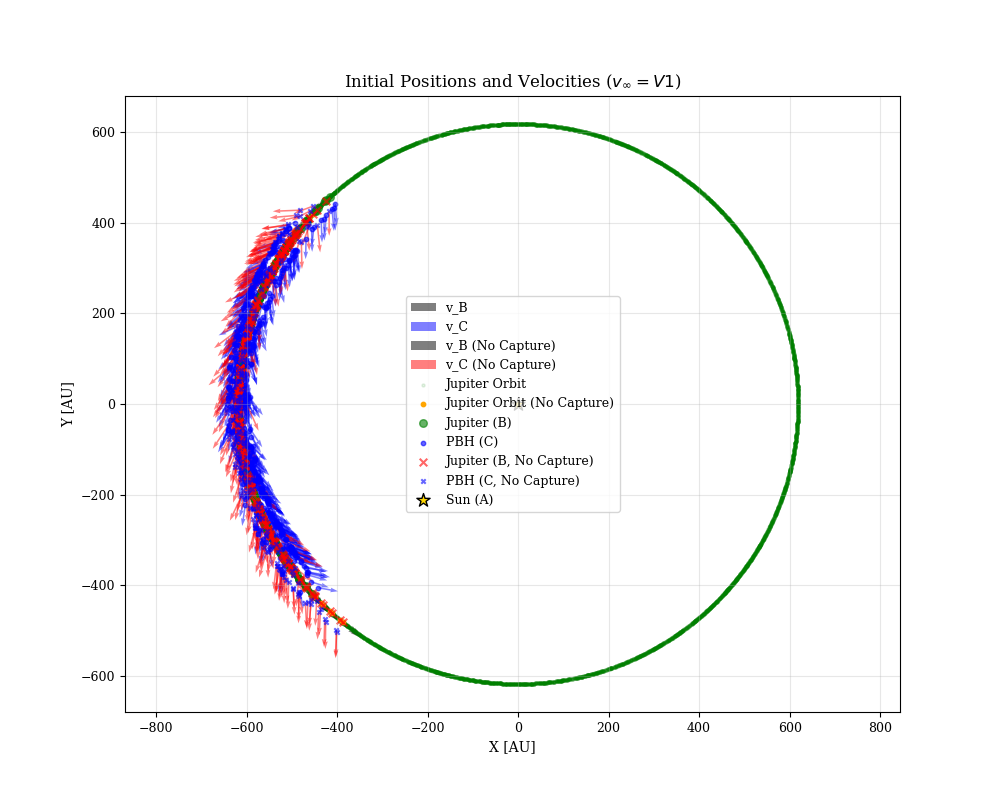

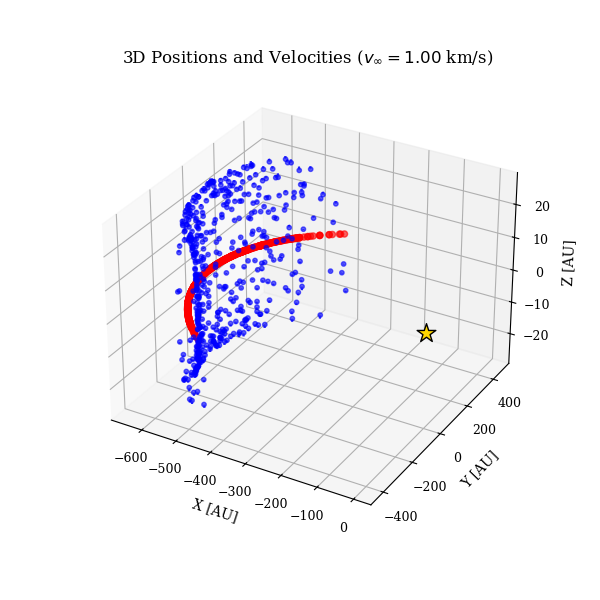

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
# Get data from sampled_mc
sampled_mc = runs_dict['run_5']['sampled_mc']
# m = list(sampled_mc.keys())[4]  # First velocity key
m = list(sampled_mc.keys())[0]  # Choose a velocity key

plt.close('all')
# Extract positions and velocities (in AU and AU/yr)
pos_C = (np.array(sampled_mc[m]['cap_C_pos']) * u.m).to(u.au).value
pos_B = (np.array(sampled_mc[m]['cap_B_pos']) * u.m).to(u.au).value
v_C = (np.array(sampled_mc[m]['cap_C_v2']) * u.m/u.s).to(u.au/u.yr).value
v_B = (np.array(sampled_mc[m]['cap_B_v']) * u.m/u.s).to(u.au/u.yr).value
nocap_pos_C = (np.array(sampled_mc[m]['nocap_C_pos']) * u.m).to(u.au).value
nocap_pos_B = (np.array(sampled_mc[m]['nocap_B_pos']) * u.m).to(u.au).value
nocap_v_C = (np.array(sampled_mc[m]['nocap_C_v2']) * u.m/u.s).to(u.au/u.yr).value
nocap_v_B = (np.array(sampled_mc[m]['nocap_B_v']) * u.m/u.s).to(u.au/u.yr).value
v_inf = (np.array(sampled_mc[m]['v_inf']) * u.m/u.s).to(u.km/u.s).value
lambda_all = (np.array(sampled_mc[m]['all_lambda']))
lambda_nocap = (np.array(sampled_mc[m]['nocap_lambda']))
aB = (np.array(catalog['aB']))
velocities_in_B_frame = v_C - v_B  # Relative velocity of PBH in Jupiter's frame
# # # 2D plot (XY plane)
rABVec = np.array([calc.r_AB_vec(aB, lambda_all[i]) for i in range(len(lambda_all))])* u.m.to(u.au)
fig, ax = plt.subplots(figsize=(10, 8))
rABVec_nocap = np.array([calc.r_AB_vec(aB, lambda_nocap[i]) for i in range(len(lambda_nocap))])* u.m.to(u.au)

# Plot positions


# Plot velocity vectors (scaled for visibility)
scale = 0.05  # Adjust this to make arrows visible
ax.quiver(pos_B[:, 0], pos_B[:, 1], v_B[:, 0]*scale, v_B[:, 1]*scale, 
          color='black', alpha=0.5, width=0.003, label='v_B' )
ax.quiver(pos_C[:, 0], pos_C[:, 1], v_C[:, 0]*scale, v_C[:, 1]*scale, 
          color='blue', alpha=0.5, width=0.002, label='v_C')
ax.quiver(nocap_pos_B[:, 0], nocap_pos_B[:, 1], nocap_v_B[:, 0]*scale, nocap_v_B[:, 1]*scale, 
          color='black', alpha=0.5, width=0.003, label='v_B (No Capture)')
ax.quiver(nocap_pos_C[:, 0], nocap_pos_C[:, 1], nocap_v_C[:, 0]*scale, nocap_v_C[:, 1]*scale, 
          color='red', alpha=0.5, width=0.002, label='v_C (No Capture)')
ax.scatter(rABVec[:, 0], rABVec[:, 1], c='green', label='Jupiter Orbit', s=5, alpha=0.1)
ax.scatter(rABVec_nocap[:, 0], rABVec_nocap[:, 1], c='orange', label='Jupiter Orbit (No Capture)', s=10, alpha=1)
ax.scatter(pos_B[:, 0], pos_B[:, 1], c='green', label='Jupiter (B)', s=30, alpha=0.6)
ax.scatter(pos_C[:, 0], pos_C[:, 1], c='blue', label='PBH (C)', s=10, alpha=0.6)
ax.scatter(nocap_pos_B[:, 0], nocap_pos_B[:, 1], c='red', label='Jupiter (B, No Capture)', s=30, alpha=0.6, marker='x')
ax.scatter(nocap_pos_C[:, 0], nocap_pos_C[:, 1], c='blue', label='PBH (C, No Capture)', s=10, alpha=0.6, marker='x')
ax.scatter(0, 0, c='gold', s=100, marker='*', label='Sun (A)', edgecolors='black')
ax.set_xlabel('X [AU]')
ax.set_ylabel('Y [AU]')
ax.set_title(rf'Initial Positions and Velocities ($v_\infty = {m}$)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.show()

# 3D plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pos_B[:, 0], pos_B[:, 1], pos_B[:, 2], c='red', label='Jupiter (B)', s=20, alpha=0.6)
ax.scatter(pos_C[:, 0], pos_C[:, 1], pos_C[:, 2], c='blue', label='PBH (C)', s=10, alpha=0.6)
ax.scatter(0, 0, 0, c='gold', s=200, marker='*', label='Sun (A)', edgecolors='black')

# 3D velocity vectors
# ax.quiver(pos_B[:, 0], pos_B[:, 1], pos_B[:, 2], 
#           v_B[:, 0]*scale, v_B[:, 1]*scale, v_B[:, 2]*scale,
#           color='red', alpha=0.5, arrow_length_ratio=0.3)
ax.quiver(pos_C[:, 0], pos_C[:, 1], pos_C[:, 2],
          v_C[:, 0]*scale, v_C[:, 1]*scale, v_C[:, 2]*scale,
          color='blue', alpha=0.5, arrow_length_ratio=0.3)

ax.set_xlabel('X [AU]')
ax.set_ylabel('Y [AU]')
ax.set_zlabel('Z [AU]')
ax.set_title(fr'3D Positions and Velocities ($v_\infty = {v_inf:.2f}$ km/s)')
# ax.legend()
plt.show()

In [51]:
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    # print(catalog.keys())
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print(catalog['total_occurrences_gl']['capture_rate_gl'])
    print(catalog['total_occurrences_gl']['termination_rate_gl'])
    print(catalog['total_occurrences_gl']['capture_rate_gl']/catalog['total_occurrences_gl']['termination_rate_gl'])
    # print(catalog['total_occurrences_gl']['total_systems_neq_2_gl'])
    # # print(catalog['V1']['occurrences'])
    # # analysis.print_detailed_catalog_summary()
    # analysis.print_termination_counts_summary()
    print("...............................")

run_1:
232603326.2236755
74.2616890293055
1.5386372346174196e-05
4826458.5932609765
...............................
run_2:
254509166.2726758
76.20563439464891
1.4735841124190977e-05
5171447.883592239
...............................
run_3:
263825376.94480434
79.83430437281999
1.4670852794699627e-05
5441694.868730671
...............................
run_4:
302694017.0719155
88.25223865802225
1.4805372521497368e-05
5960825.270007911
...............................
run_5:
1645610642.5268648
215.5989769887824
7.533873390662532e-06
28617281.68354878
...............................


In [ ]:
collided_sys = 0
collided_BC = 0
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    v_keys = [k for k in catalog.keys() if isinstance(k, str) and k.startswith('V')]
    
    for v in v_keys:
        rebounddata = analysis.get_combined_dictionary()[v]['rebound']
        
        for d in rebounddata:
            flag = d['termination_flag']
            if 'collision' in str(flag):
                collided_sys += 1
                print(f"Found collision in {run} with termination flag: {flag}")
                collided_pair = d['collision_info']
                print(f"  Collided pair: {collided_pair}")
                if 'B-C' in str(collided_pair) or 'C-B' in str(collided_pair):
                    collided_BC += 1
    print("...............................")
print(f"Total collisions: {collided_sys}")
print(f"Total B-C collisions: {collided_BC}")
    # analysis.print_termination_counts_summary()


run_1:
Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound entries found.
Combining V114: MC data found, 500 Rebound entries found.
Combining V142: MC data found, 500 Rebound entries found.
Combining V170: MC data found, 500 Rebound entries found.
Combining V198: MC data found, 500 Rebound entries found.
Combining V226: MC data found, 500 Rebound entries found.
Combining V255: MC data found, 500 Rebound entries found.
Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Re

In [47]:
# new
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    analysis.print_detailed_catalog_summary()
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print(catalog['total_occurrences_gl']['total_systems_neq_2_gl'])
    # analysis.print_termination_counts_summary()
    print("...............................")

run_1:
Velocity bin: V1, sampled capture count 500total capture count: 500 out of 0 samples,sigma_MC_dsigma_au2: N/A, satisfied conditions- bmax>bmin, b>bmin, E_sys<0, E_cap<0: [10386   797   797   693   500]
V1 non-zero termination counts:
  escape_C_count: 472
  time_exceeded_count: 4
  completed_count: 24
--------------------------------
Velocity bin: V29, sampled capture count 500total capture count: 500 out of 0 samples,sigma_MC_dsigma_au2: N/A, satisfied conditions- bmax>bmin, b>bmin, E_sys<0, E_cap<0: [5683  841  841  734  500]
V29 non-zero termination counts:
  escape_C_count: 462
  time_exceeded_count: 2
  completed_count: 36
--------------------------------
Velocity bin: V57, sampled capture count 500total capture count: 500 out of 0 samples,sigma_MC_dsigma_au2: N/A, satisfied conditions- bmax>bmin, b>bmin, E_sys<0, E_cap<0: [3797  669  669  611  500]
V57 non-zero termination counts:
  escape_C_count: 430
  time_exceeded_count: 6
  collision_count_rebound: 1
  completed_count

In [ ]:
# OLD
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    analysis.print_detailed_catalog_summary()
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print(catalog['total_occurrences_gl']['total_systems_neq_2_gl'])
    # analysis.print_termination_counts_summary()
    print("...............................")

run_1:
Velocity bin: v1, sampled capture count 200 total capture count: 200 out of 3468 samples, sampled cross section size: None
v1 non-zero termination counts:
  escape_C_count: 194
  time_exceeded_count: 1
  completed_count: 5
--------------------------------
Velocity bin: v29, sampled capture count 200 total capture count: 200 out of 3484 samples, sampled cross section size: None
v29 non-zero termination counts:
  escape_C_count: 186
  completed_count: 14
--------------------------------
Velocity bin: v57, sampled capture count 200 total capture count: 200 out of 3099 samples, sampled cross section size: None
v57 non-zero termination counts:
  escape_C_count: 189
  time_exceeded_count: 1
  completed_count: 10
--------------------------------
Velocity bin: v86, sampled capture count 200 total capture count: 200 out of 3106 samples, sampled cross section size: None
v86 non-zero termination counts:
  escape_C_count: 191
  completed_count: 9
--------------------------------
Velocity bi

In [6]:
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']

    v_keys = sorted([k for k in catalog.keys() if isinstance(k, str) and k.startswith('V')],
                    key=lambda x: int(x[1:]))

    v_inf_values = [catalog[k]['v_inf_au_yr'] for k in v_keys]

    cross_section = [(catalog[k]['sigma_MC_m2'] * u.m**2).to(u.au**2).value for k in v_keys]
    cross_section_dsigma = [catalog[k]['sigma_MC_dsigma_au2']   for k in v_keys]
    b_max_values = [catalog[k]['b_max'] for k in v_keys]
    b_values = [catalog[k]['cap_b'] for k in v_keys]
    sampled = [catalog[k]['sample_number'] for k in v_keys]
    checks = [catalog[k]['checks'] for k in v_keys]
    bmin = np.min(b_values[0])
    bmax = np.max(b_values[0])
    check = checks[0]
    coll_cross_section = [(catalog[k]['cap_collision_cross_sections'] * u.m**2).to(u.au**2).value for k in v_keys]
    cs = 2 * np.pi * (bmax-bmin) * np.sum(np.array(b_values[0])) / sampled[0]
    cs_nosum = np.pi * ((bmax**2 - bmin**2) - ((bmax-bmin)**2)/sampled[0]) * len(np.array(b_values[0])) / sampled[0]

    cs_inccol =  2 * np.pi * (bmax * np.sum(np.array(b_values[0])) / sampled[0])
    cs_col = np.sum(coll_cross_section[0])/ sampled[0]
    print(f"v_inf (au/yr): {v_inf_values[0]}")
    # print(f"sigma_MC (au^2): {cross_section[0]}")
    print(f"d_sigma_MC (au^2): {cross_section_dsigma[0]}")
    # print(f"d_sigma_MC_captured (au^2): {cross_section_dsigma_captured[0]}")
    # print(f"sigma_MC_bmax (au^2): {cross_section_bmax[0]}")
    # print(f"b_max (AU): {b_max_values[0]}")
    # print(f"b (AU): {b_values[0]}")
    print(f"sampled: {sampled[0]}")
    print(f"Checks: {check} (should equal capture count)")
    print(f"calculated cs (au^2): {(cs*u.m**2).to(u.au**2).value}")
    print(f"calculated cs_nosum (au^2): {(cs_nosum*u.m**2).to(u.au**2).value}")
    # print(f"collision_cross_section (au^2): {coll_cross_section[0]}")
    print(f"collision_cross_section calc (au^2): {(cs_inccol*u.m**2).to(u.au**2).value - cs_col}")
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print((((np.max(b_values[0])-np.min(b_values[0]))**2)*u.m**2).to(u.au**2).value/sampled[0])
    print("...............................")



run_1:
v_inf (au/yr): 0.2109495265696987
d_sigma_MC (au^2): 115.04267429549819
sampled: 797
Checks: [  797     0 10386   797   797   693   500   500] (should equal capture count)
calculated cs (au^2): 115.0426742954982
calculated cs_nosum (au^2): 383.0592596647523
collision_cross_section calc (au^2): 116.60920477089643
231171609.31929544
0.23707264763783772
...............................
run_2:
v_inf (au/yr): 0.2109495265696987
d_sigma_MC (au^2): 129.35733494092085
sampled: 792
Checks: [  792     0 10380   792   792   713   500   500] (should equal capture count)
calculated cs (au^2): 129.35733494092085
calculated cs_nosum (au^2): 384.13353855463583
collision_cross_section calc (au^2): 131.19955082055353
252624859.5552929
0.2375285028343064
...............................
run_3:
v_inf (au/yr): 0.2109495265696987
d_sigma_MC (au^2): 149.15796441367348
sampled: 787
Checks: [  787     0 10513   787   787   702   500   500] (should equal capture count)
calculated cs (au^2): 149.15796441367

Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound entries found.
Combining V114: MC data found, 500 Rebound entries found.
Combining V142: MC data found, 500 Rebound entries found.
Combining V170: MC data found, 500 Rebound entries found.
Combining V198: MC data found, 500 Rebound entries found.
Combining V226: MC data found, 500 Rebound entries found.
Combining V255: MC data found, 500 Rebound entries found.
Average time step across first 500 systems: 179.52 yr (std: 17.99 yr)

TIME STEP VERIFICATION
Target dt:      200 yr
Mean dt:        200.00 yr
Std dt:         0.00 yr
Min dt:         200.00 yr
Max dt:         200.00 yr



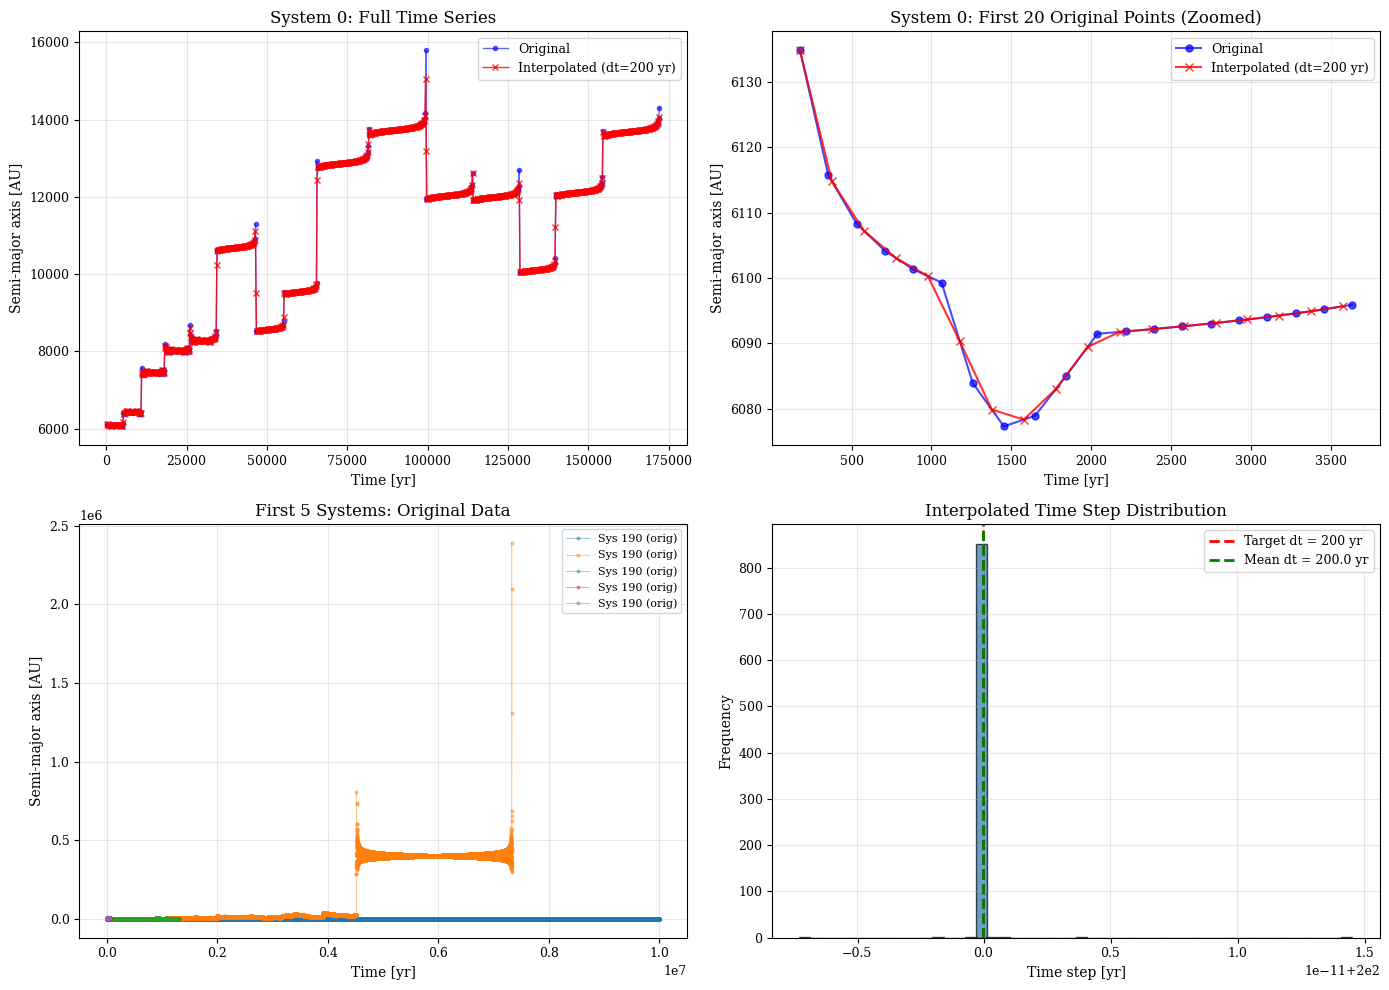


DATA COMPARISON
Original data:
  First system: 956 points
  Time range:   177.24 to 172125.51 yr
  Duration:     171948.28 yr

Interpolated data:
  Total points: 860
  Time range:   177.24 to 171977.24 yr
  Expected points (sys 0): 859

INTERPOLATION ACCURACY CHECK
Max absolute error:  1.488638e+03 AU
Mean absolute error: 1.119502e+01 AU
Max relative error:  9.4224%
Mean relative error: 0.1023%



In [148]:
import matplotlib.pyplot as plt
import numpy as np
plotobj = pl.Plots(name='test', configuration=configuration, analysis=analysis)
# Get your data
metric = [rb_entry['semi_major_axes'] for rb_entry in catalog['V255']['rebound']]
times = [rb_entry['times'] for rb_entry in catalog['V255']['rebound']]
i = 190
# Interpolate with fixed time step
dt_fixed = 200  # years
intp_times, intp_metric = plotobj.process_timeseries_metric(times, metric, dt_fixed=dt_fixed)

# Convert to arrays
intp_times = np.array(intp_times[i])
intp_metric = np.array(intp_metric[i])

# ============ PLOTTING ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: First system - full time series
ax = axes[0, 0]
ax.plot(times[i], metric[i], 'o-', markersize=3, linewidth=1, 
        alpha=0.6, label='Original', color='blue')

# Find interpolated points for this system
t_min, t_max = times[i][0], times[i][-1]
mask_sys0 = (intp_times >= t_min) & (intp_times <= t_max)
ax.plot(intp_times[mask_sys0], intp_metric[mask_sys0], 'x-', 
        markersize=4, linewidth=1, alpha=0.8, 
        label=f'Interpolated (dt={dt_fixed} yr)', color='red')

ax.set_xlabel('Time [yr]')
ax.set_ylabel('Semi-major axis [AU]')
ax.set_title('System 0: Full Time Series')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Zoom in on first 10 points
ax = axes[0, 1]
n_zoom = 20
ax.plot(times[i][:n_zoom], metric[i][:n_zoom], 'o-', 
        markersize=5, linewidth=1.5, alpha=0.7, 
        label='Original', color='blue')

# Get corresponding interpolated points
t_zoom_max = times[i][n_zoom-1]
mask_zoom = (intp_times >= times[i][0]) & (intp_times <= t_zoom_max)
ax.plot(intp_times[mask_zoom], intp_metric[mask_zoom], 'x-', 
        markersize=6, linewidth=1.5, alpha=0.8, 
        label=f'Interpolated (dt={dt_fixed} yr)', color='red')

ax.set_xlabel('Time [yr]')
ax.set_ylabel('Semi-major axis [AU]')
ax.set_title(f'System 0: First {n_zoom} Original Points (Zoomed)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Multiple systems overlaid (original)
ax = axes[1, 0]
for j in range(min(5, len(times))):  # Plot first 5 systems
    ax.plot(times[j], metric[j], 'o-', markersize=2, 
            linewidth=0.8, alpha=0.4, label=f'Sys {i} (orig)')
m = [np.diff(times[j]).mean() for j in range(len(times))]
print(f"Average time step across first 500 systems: {np.mean(m):.2f} yr (std: {np.std(m):.2f} yr)")

ax.set_xlabel('Time [yr]')
ax.set_ylabel('Semi-major axis [AU]')
ax.set_title('First 5 Systems: Original Data')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 4: Interpolated data - show uniform time spacing
ax = axes[1, 1]
# Calculate time differences to verify uniform spacing
if len(intp_times) > 1:
    dt_actual = np.diff(intp_times)
    
    # Histogram of time steps
    ax.hist(dt_actual, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(dt_fixed, color='red', linestyle='--', linewidth=2, 
               label=f'Target dt = {dt_fixed} yr')
    
    # Add statistics
    dt_mean = np.mean(dt_actual)
    dt_std = np.std(dt_actual)
    ax.axvline(dt_mean, color='green', linestyle='--', linewidth=2, 
               label=f'Mean dt = {dt_mean:.1f} yr')
    
    ax.set_xlabel('Time step [yr]')
    ax.set_ylabel('Frequency')
    ax.set_title('Interpolated Time Step Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    print(f"\n{'='*60}")
    print(f"TIME STEP VERIFICATION")
    print(f"{'='*60}")
    print(f"Target dt:      {dt_fixed} yr")
    print(f"Mean dt:        {dt_mean:.2f} yr")
    print(f"Std dt:         {dt_std:.2f} yr")
    print(f"Min dt:         {np.min(dt_actual):.2f} yr")
    print(f"Max dt:         {np.max(dt_actual):.2f} yr")
    print(f"{'='*60}\n")

plt.tight_layout()
plt.show()

# ============ ADDITIONAL VERIFICATION ============
print(f"\n{'='*60}")
print(f"DATA COMPARISON")
print(f"{'='*60}")
print(f"Original data:")
print(f"  First system: {len(times[i])} points")
print(f"  Time range:   {times[i][0]:.2f} to {times[i][-1]:.2f} yr")
print(f"  Duration:     {times[i][-1] - times[i][0]:.2f} yr")
print(f"\nInterpolated data:")
print(f"  Total points: {len(intp_times)}")
print(f"  Time range:   {intp_times[0]:.2f} to {intp_times[-1]:.2f} yr")
print(f"  Expected points (sys 0): {int((times[i][-1] - times[i][0]) / dt_fixed)}")
print(f"{'='*60}\n")

# ============ CHECK INTERPOLATION ACCURACY ============
# Sample a few points from original and compare to interpolated
from scipy.interpolate import interp1d

print(f"{'='*60}")
print(f"INTERPOLATION ACCURACY CHECK")
print(f"{'='*60}")

# Check first system
times_orig = times[i]
metric_orig = metric[i]

# Create interpolator from interpolated data
f_check = interp1d(intp_times, intp_metric, kind='linear', 
                   bounds_error=False, fill_value='extrapolate')

# Sample at original time points
metric_resampled = f_check(times_orig)

# Calculate errors
errors = np.abs(metric_resampled - metric_orig)
rel_errors = errors / (np.abs(metric_orig) + 1e-10)  # Avoid division by zero

print(f"Max absolute error:  {np.max(errors):.6e} AU")
print(f"Mean absolute error: {np.mean(errors):.6e} AU")
print(f"Max relative error:  {np.max(rel_errors)*100:.4f}%")
print(f"Mean relative error: {np.mean(rel_errors)*100:.4f}%")
print(f"{'='*60}\n")

In [156]:
allt, allm = [], []
intp_times_masked, intp_metrics_masked = [], []
intp_times, intp_metrics = [], []
catalog = runs_dict['run_1']['catalog']
analysis = runs_dict['run_1']['analysis']
for v in v_keys:
    metric = [rb_entry['semi_major_axes'] for rb_entry in catalog[v]['rebound']]
    times = [rb_entry['times'] for rb_entry in catalog[v]['rebound']]
    times_flat = np.concatenate(times)
    metric_flat = np.concatenate(metric)
    allt.extend(times_flat)
    allm.extend(metric_flat)
    dt_fixed = 170  # years
    intp_time, intp_metric = plotobj.process_timeseries_metric(times, metric, dt_fixed=dt_fixed)
    intp_times_flat = np.concatenate(intp_time)
    intp_metrics_flat = np.concatenate(intp_metric)
    intp_times.extend(intp_times_flat)
    intp_metrics.extend(intp_metrics_flat)
    metric_mask = {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    }
    mask = plotobj.resolve_mask(analysis, metric_mask, v)
    if mask is not None:
        mask = np.asarray(mask)
        metric_masked = [m for j, m in enumerate(metric) if mask[j]]
        time_masked = [m for j, m in enumerate(times) if mask[j]]
    intp_time_masked, intp_metric_masked = plotobj.process_timeseries_metric(time_masked, metric_masked, dt_fixed=dt_fixed)
    times_flat_masked = np.concatenate(intp_time_masked)
    metrics_flat_masked = np.concatenate(intp_metric_masked)
    intp_times_masked.extend(times_flat_masked)
    intp_metrics_masked.extend(metrics_flat_masked)



In [155]:
means = []
for v in v_keys:
    metric = [rb_entry['semi_major_axes'] for rb_entry in catalog[v]['rebound']]
    times = [rb_entry['times'] for rb_entry in catalog[v]['rebound']]
    
    # ✅ Filter out None and empty arrays
    valid = [j for j in range(len(times)) 
             if times[j] is not None and len(times[j]) > 1]  # Need at least 2 points for diff
    
    if len(valid) == 0:
        print(f"Average time step for {v}: No valid data")
        continue
    
    m = [np.diff(times[j]).mean() for j in valid]
    
    # ✅ Check if m has valid values
    if len(m) == 0 or all(np.isnan(m)):
        print(f"Average time step for {v}: No valid time steps")
    else:
        mean_dt = np.nanmean(m)  # Use nanmean to ignore any remaining NaNs
        std_dt = np.nanstd(m)
        print(f"Average time step for {v}: {mean_dt:.2f} yr (std: {std_dt:.2f} yr)")
    means.append((mean_dt, std_dt))
print(f"Overall average time step across all systems: {np.mean([m[0] for m in means]):.2f} yr (std: {np.mean([m[1] for m in means]):.2f} yr)")

Average time step for V1: 175.52 yr (std: 24.73 yr)
Average time step for V29: 177.50 yr (std: 20.10 yr)
Average time step for V57: 170.62 yr (std: 35.87 yr)
Average time step for V86: 169.41 yr (std: 34.98 yr)
Average time step for V114: 162.70 yr (std: 43.40 yr)
Average time step for V142: 161.47 yr (std: 42.92 yr)
Average time step for V170: 159.18 yr (std: 48.89 yr)
Average time step for V198: 164.03 yr (std: 41.88 yr)
Average time step for V226: 170.26 yr (std: 33.78 yr)
Average time step for V255: 179.52 yr (std: 17.99 yr)
Overall average time step across all systems: 169.02 yr (std: 34.45 yr)


[1. 1. 1. ... 1. 1. 1.]


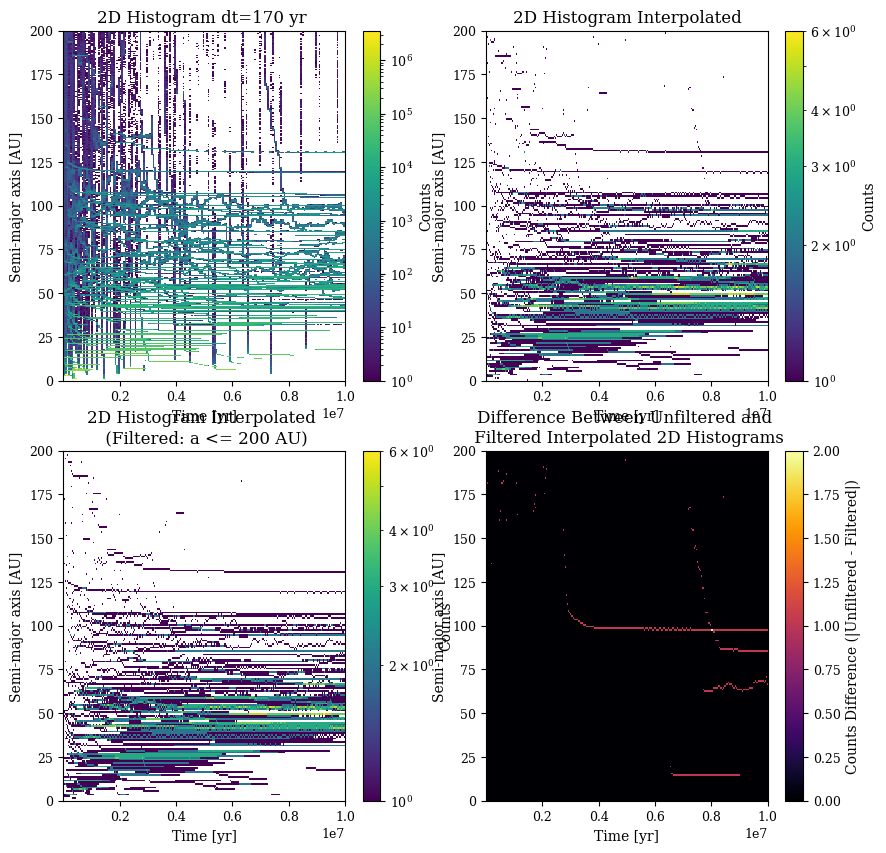

In [157]:
from matplotlib.colors import LogNorm

time_bins, metric_bins = dt_fixed, 1000

# Flatten by concatenating all time series
times_flat = np.array(allt)
metric_flat = np.array(allm)

h, xedges, yedges = np.histogram2d(
    times_flat, 
    metric_flat,
    bins=[time_bins, metric_bins],
    range=[(times_flat.min(), times_flat.max()), (0,200)])
norm_obj = LogNorm(vmin=1, vmax=h.max())

# ✅ Create figure and axis
fig, ax = plt.subplots(2,2, figsize=(10, 10))

# Plot
pcm = ax[0, 0].pcolormesh(
    xedges, yedges, h.T,
    rasterized=True,
    shading='auto',
    norm=norm_obj,
    cmap='viridis'  # Optional: specify colormap
)

# Add colorbar
cbar = fig.colorbar(pcm, ax=ax[0, 0], label='Counts')

# Labels
ax[0, 0].set_xlabel('Time [yr]')
ax[0, 0].set_ylabel('Semi-major axis [AU]')
ax[0, 0].set_title(f'2D Histogram dt={dt_fixed} yr ')

from matplotlib.colors import LogNorm


time_bins, metric_bins = dt_fixed, 200
# times_flat = np.concatenate(intp_times)
# metric_flat = np.concatenate(intp_metric)
times_flat = np.array(intp_times)
metric_flat = np.array(intp_metrics)
# Flatten by concatenating all time series
bin_width = dt_fixed # years
time_min, time_max = times_flat.min(), times_flat.max()
time_bins = np.arange(time_min, time_max + bin_width, bin_width)


h, xedges, yedges = np.histogram2d(
    times_flat, 
    metric_flat,
    bins=[time_bins, metric_bins],
    range=[(times_flat.min(), times_flat.max()), (0,200)])
norm_obj = LogNorm(vmin=1, vmax=h.max())

# Plot
pcm = ax[0, 1].pcolormesh(
    xedges, yedges, h.T,
    rasterized=True,
    shading='auto',
    norm=norm_obj,
    cmap='viridis'  # Optional: specify colormap
)

# Add colorbar
cbar = fig.colorbar(pcm, ax=ax[0, 1], label='Counts')

# Labels
ax[0, 1].set_xlabel('Time [yr]')
ax[0, 1].set_ylabel('Semi-major axis [AU]')
ax[0, 1].set_title('2D Histogram Interpolated')



times_filtered = np.array(intp_times_masked)
metric_filtered = np.array(intp_metrics_masked)

time_bins = np.arange(times_filtered.min(), times_filtered.max() + dt_fixed, dt_fixed)
h2, xedges2, yedges2 = np.histogram2d(
    times_filtered, 
    metric_filtered,
    bins=[time_bins, metric_bins],
    range=[(times_filtered.min(), times_filtered.max()), (0,200)])
norm_obj2 = LogNorm(vmin=1, vmax=h2.max())
# ✅ Create figure and axis
# Plot
pcm2 = ax[1, 0].pcolormesh(
    xedges2, yedges2, h2.T,
    rasterized=True,
    shading='auto',
    norm=norm_obj2,
    cmap='viridis'  # Optional: specify colormap
)
# Add colorbar
cbar2 = fig.colorbar(pcm2, ax=ax[1, 0], label='Counts')
# Labels
ax[1, 0].set_xlabel('Time [yr]')
ax[1, 0].set_ylabel('Semi-major axis [AU]')
ax[1, 0].set_title(f'2D Histogram Interpolated \n (Filtered: a <= {200} AU)')
# plot difference image

h_diff = h - h2
print(h_diff[h_diff >0])
pcm_diff = ax[1, 1].pcolormesh(
    xedges, yedges, (h_diff).T,
    rasterized=True,
    shading='auto',
    cmap='inferno'  # Optional: specify colormap
)
cbar_diff = fig.colorbar(pcm_diff, ax=ax[1, 1], label='Counts Difference (|Unfiltered - Filtered|)')
ax[1, 1].set_xlabel('Time [yr]')
ax[1, 1].set_ylabel('Semi-major axis [AU]')
ax[1, 1].set_title('Difference Between Unfiltered and \n Filtered Interpolated 2D Histograms')
plt.show()

Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound entries found.
Combining V114: MC data found, 500 Rebound entries found.
Combining V142: MC data found, 500 Rebound entries found.
Combining V170: MC data found, 500 Rebound entries found.
Combining V198: MC data found, 500 Rebound entries found.
Combining V226: MC data found, 500 Rebound entries found.
Combining V255: MC data found, 500 Rebound entries found.


/data/a.saricaoglu/repo/captus/src/plotting/Plotting_v2.py:228: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon=False, loc='upper center', ncol=2)


Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound entries found.
Combining V114: MC data found, 500 Rebound entries found.
Combining V142: MC data found, 500 Rebound entries found.
Combining V170: MC data found, 500 Rebound entries found.
Combining V198: MC data found, 500 Rebound entries found.
Combining V226: MC data found, 500 Rebound entries found.
Combining V255: MC data found, 500 Rebound entries found.
Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound e

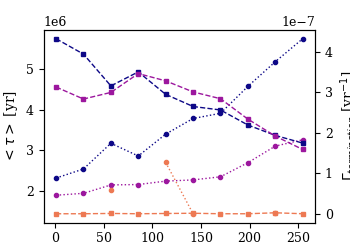

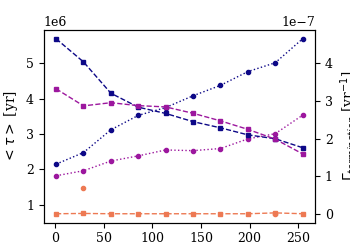

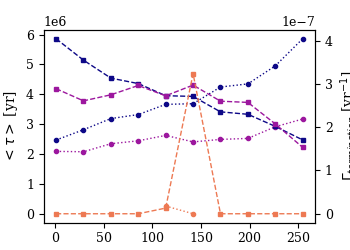

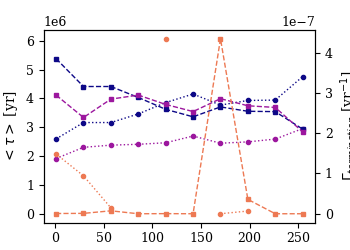

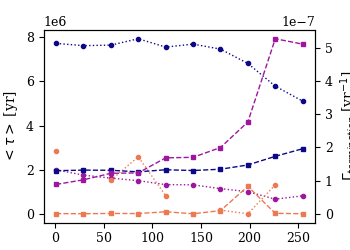

In [19]:
for run in runs_dict.keys():
    analysis = runs_dict[run]['analysis']
    name = analysis.name
    plotobj = pl.Plots(name=name, analysis=[analysis])
    mlist1 = ['total_rate','ejection_rate','collision_rate']
    mlabels1 = ['Total', 'Ejected', 'Collided']
    mylabel1 =r'$\Gamma_{termination}$ [yr$^{-1}$]'
    mlist3 = ['average_lifetime_total','average_lifetime_ejected','average_lifetime_collided']
    mlabels3 = ['Total', 'Ejected', 'Collided']
    mylabel3 =r'$<\tau>$ [yr]'
    mlists = [mlist3, mlist1]
    mlabels = [mlabels3, mlabels1]
    mylabels = [mylabel3, mylabel1]
    plotobj.plot_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=None, analysis_name=name, save=False)

In [5]:
analysis_list = []
for run in runs_dict.keys():
    analysis = runs_dict[run]['analysis']
    analysis_list.append(analysis)

In [58]:
print(1.98840987e+26/const.M_jup.value)

0.1047565514292719


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<unknown>:689: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1618: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1826: SyntaxWarning: invalid escape sequence '\%'
<unknown>:689: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1618: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1826: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_12288/1071828071.py:2: SyntaxWarning: invalid escape sequence '\s'
  mlabels0 = [ '$\sigma_{cap}$']


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓

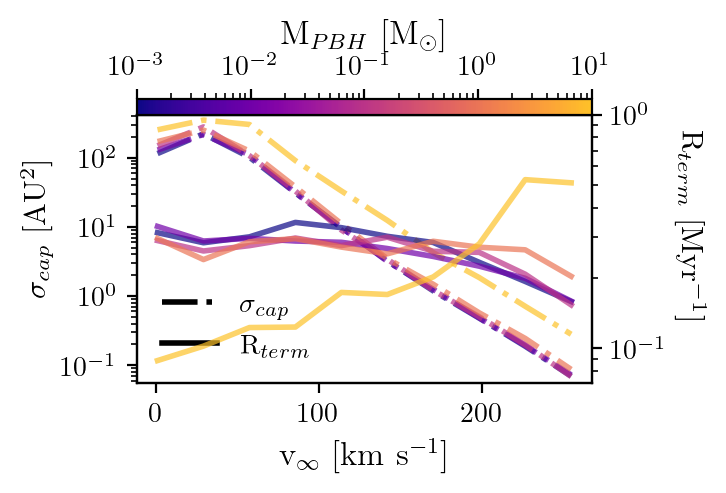

In [61]:
mlist0 = ['capture_cross_section_total']
mlabels0 = [ '$\sigma_{cap}$']
mylabel0 =r'$\sigma_{cap}$ [AU$^{2}$]'
mlist1 = ['termination_rate']
# mlabels1 = ['$d$N$_{eq}$/$d$v$_\infty$']
# mylabel1 =r'$d$N$_{eq}$/$d$v$_\infty$ [n$_\infty$ AU$^{2}$]'
mlabels1 = [r'R$_{term}$']
mylabel1 =r'R$_{term}$ [Myr$^{-1}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj2.multiple_analysis_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=mlabels, scale=['linear', 'log', 'log'], analysis_key= 'All', v_key='All', global_ylim=True, match_colors='analysis', unit_change=[1e-3, 1, 1e6], ticks=[None, None, ( 1e-1, 1)], normalize=False, save=True, fig_size=(3.5,2))

Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound entries found.
Combining V114: MC data found, 500 Rebound entries found.
Combining V142: MC data found, 500 Rebound entries found.
Combining V170: MC data found, 500 Rebound entries found.
Combining V198: MC data found, 500 Rebound entries found.
Combining V226: MC data found, 500 Rebound entries found.
Combining V255: MC data found, 500 Rebound entries found.
Combining results for v bins: ['V1', 'V29', 'V57', 'V86', 'V114', 'V142', 'V170', 'V198', 'V226', 'V255']
Combining V1: MC data found, 500 Rebound entries found.
Combining V29: MC data found, 500 Rebound entries found.
Combining V57: MC data found, 500 Rebound entries found.
Combining V86: MC data found, 500 Rebound e

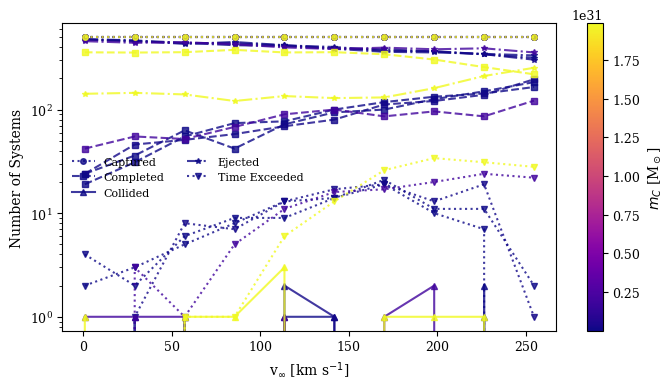

In [15]:
plotobj2 = pl.Plots(name="OCenturiNew", analysis=analysis_list, exclude_zero_capture=True)
metric_list = ['n_captured', 'completed_count', 'collision_count_rebound', 'escape_C_count', 'time_exceeded_count']
metric_labels = ['Captured', 'Completed', 'Collided', 'Ejected', 'Time Exceeded']
mylabel = 'Number of Systems'
plotobj2.multiple_analysis_metric_wrt_v(metric_list=metric_list, metric_ylabel=mylabel, metric_labels=metric_labels, analysis_key= 'All', v_key='All', save=True)

<unknown>:689: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1618: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1826: SyntaxWarning: invalid escape sequence '\%'
<unknown>:689: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1624: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1832: SyntaxWarning: invalid escape sequence '\%'


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict

📊 Processing metric 1/2: semi_major_axes
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found 

{}

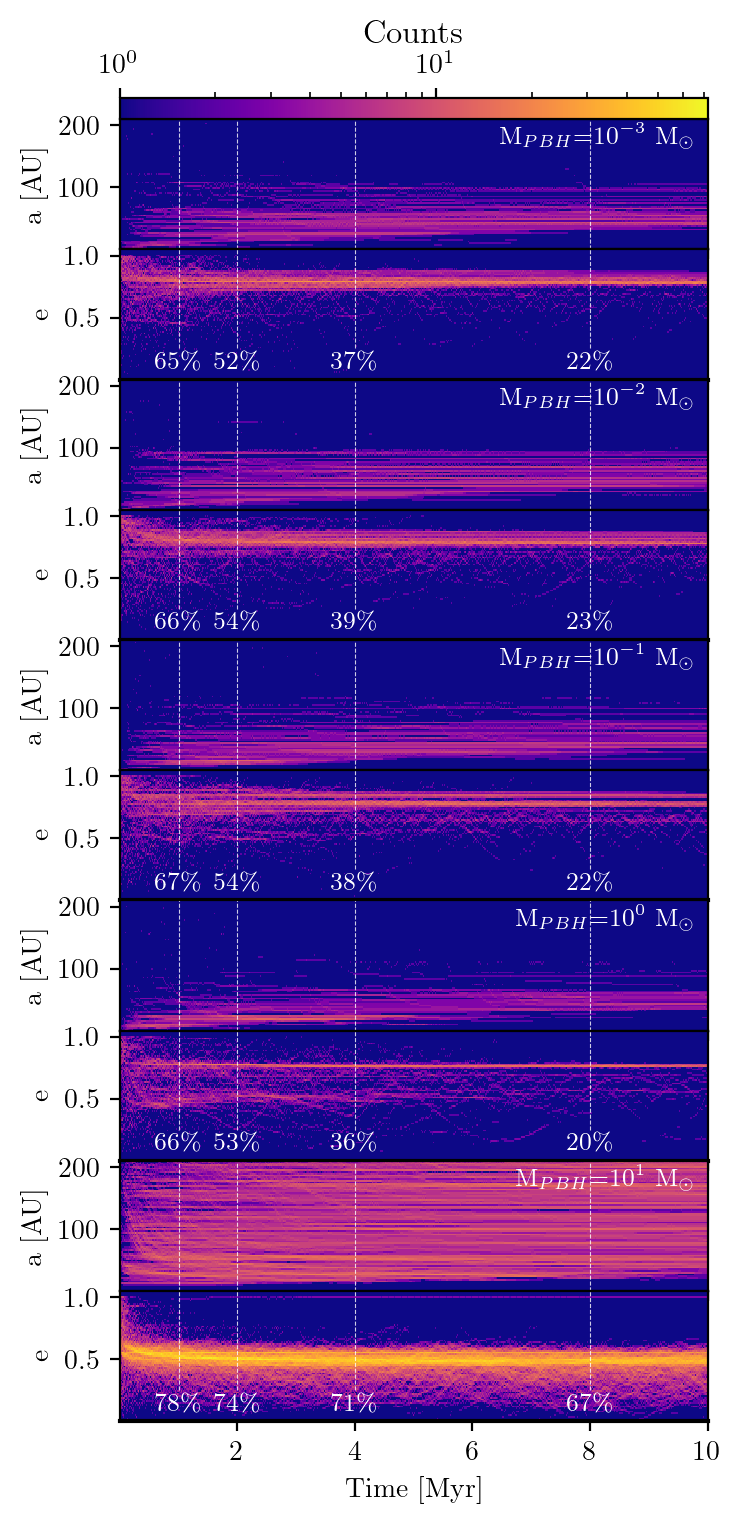

In [62]:
plotobj2.multiple_analysis_time_series_2dhistogram_multipanel_stacked(
    metric_names=['semi_major_axes', 'eccentricities'],
    metric_ylabels=[r'a [AU]', r'e'],
    time_ylabel=r'Time [Myr]',
    metric_ranges=[(0, 210), (0, 1.05)],
    ticks=[None, [100, 200], [0.5, 1.0], None],
    scale=['linear', 'linear', 'linear', 'log'],
    survivor_per_at_t = [1e6, 2e6, 4e6, 8e6],
    unit_change=[1e-6, 1, 1],
    dt_fixed=170,
    metric_bins=75,
    metric_masks=[None,
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    }], # No mask for orbital_periods
    fig_size=(3.5, 7),  # Tall figure for 5 analyses × 2 metrics
    save_as='stacked_timeseries_histograms.png'
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_co

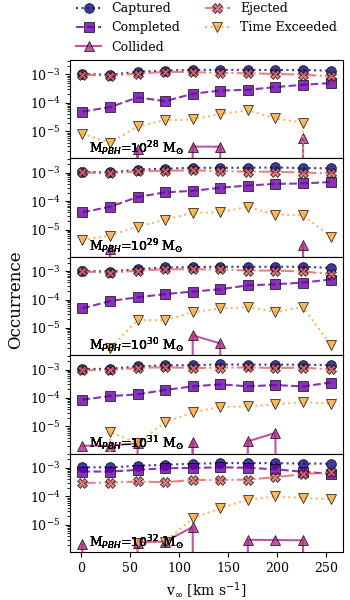

In [23]:
mylabel = 'Occurrence'
plotobj2.multiple_analysis_metric_wrt_v_multipanel(metric_list=metric_list, metric_ylabel=mylabel, metric_labels=metric_labels, analysis_key= 'All', v_key='All', normalize='sample_number', save=True,fig_size=(3.5,6))

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in 

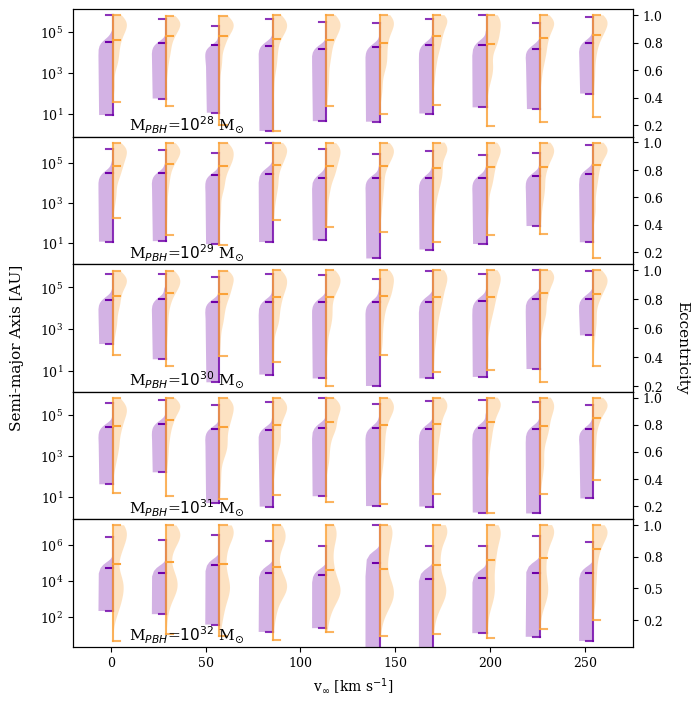

In [37]:
mlist_left = ['semi_major_axes']
mlist_right = ['eccentricities']
mlabels_left = 'Semi-major Axis [AU]'
mlabels_right = 'Eccentricity'

plotobj2.multiple_analysis_metric_array_wrt_v_twinaxis_multipanel(
    metric_lists=[mlist_left, mlist_right],
    metric_ylabels=[mlabels_left, mlabels_right],
    scale=['log','linear'],
    analysis_key='All',
    v_key='All',
    global_ylim=False,
    save=True
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓

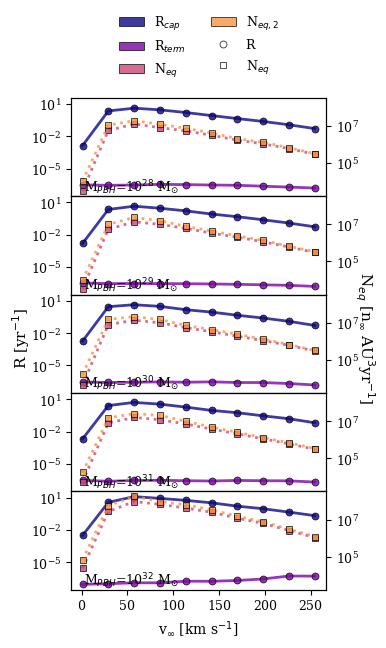

In [10]:
mlist0 = ['capture_rate', 'termination_rate']
mlabels0 = ['R$_{cap}$', 'R$_{term}$']
mylabel0 =r'R [yr$^{-1}$]'
mlist1 = ['total_systems_neq', 'total_systems_neq_2']
mlabels1 = ['N$_{eq}$', 'N$_{eq,2}$']
mylabel1 =r'N$_{eq}$ [n$_\infty$ AU$^{3}$yr$^{-1}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj2.multiple_analysis_metric_wrt_v_twinaxis_multipanel(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=mlabels, scale=['linear', 'log', 'log'], analysis_key= 'All', v_key='All', global_ylim=True, match_colors=False, unit_change=[1e-3, 1, 1], normalize=False, save=True, fig_size=(3.5,6))

In [17]:
print(analysis.name)

OmegaCenturiBH_MS_s104_calcv3_MCv4_reboundV4


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in 

{}

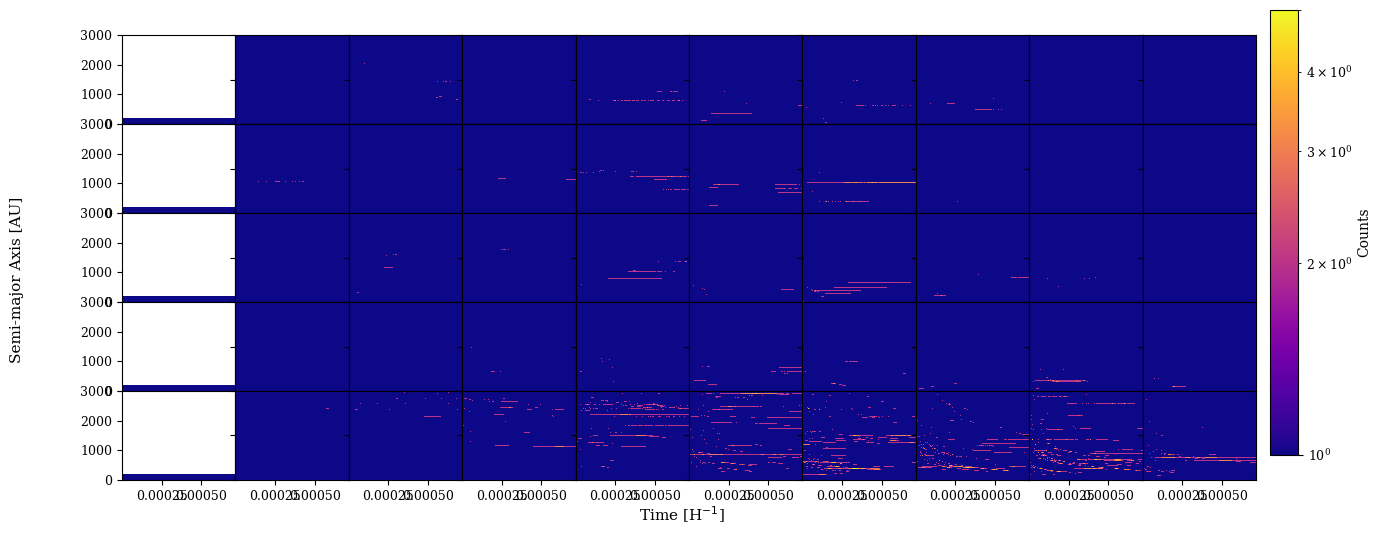

In [169]:
plotobj2.multiple_analysis_time_series_2dhistogram(
    metric_name='semi_major_axes',        # ← Keyword arg
    metric_ylabel=r'Semi-major Axis [AU]',  # ← Keyword arg
    time_ylabel=r'Time [H$^{-1}$]',
    scale=['linear', 'linear', 'log'],
    use_existing_time_series=False,
    metric_range=[0,200],
    metric_bins=200,
    dt_fixed=170,
    unit_change=[H, 1, 1],
    global_ylim=False,
    ticks=[None,(0, 1000, 2000, 3000), None],
 # No mask for orbital_periods
    save_as='semi_major_axis_time_series_histogram_a200_dt170.png',
    fig_size=(14, 5),
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in 

{}

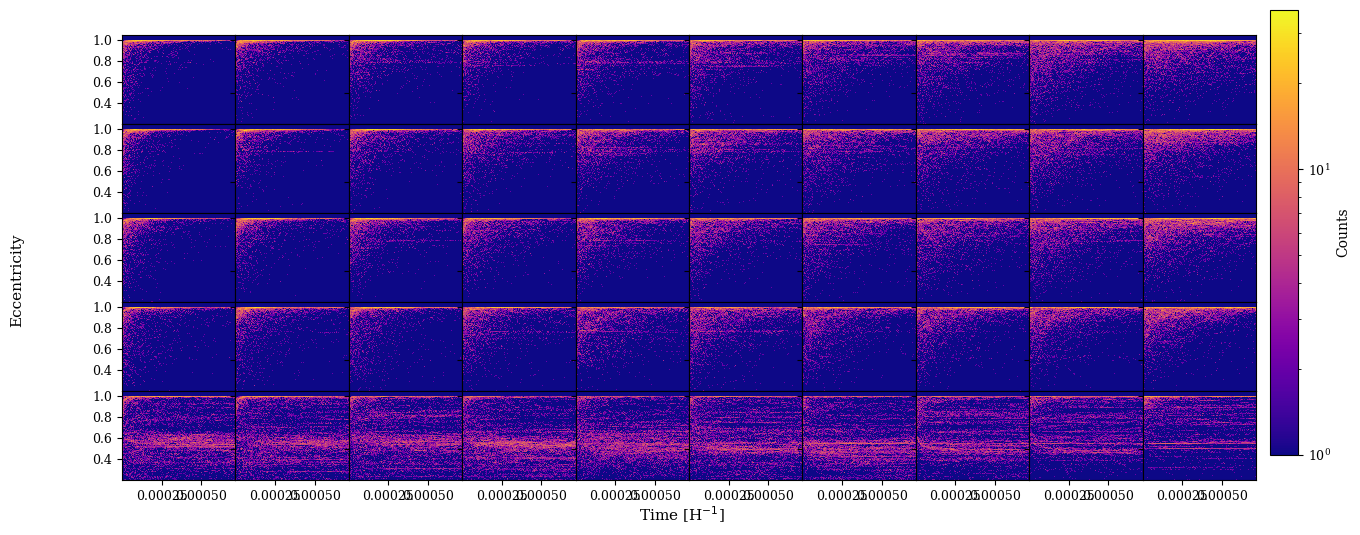

In [170]:
plotobj2.multiple_analysis_time_series_2dhistogram(
    metric_name='eccentricities',        # ← Keyword arg
    metric_ylabel=r'Eccentricity',  # ← Keyword arg
    time_ylabel=r'Time [H$^{-1}$]',
    scale=['linear', 'linear', 'log'],
    use_existing_time_series=False,
    metric_range=[0.2,1.05],
    metric_bins=200,
    dt_fixed=170,
    unit_change=[H, 1, 1],
    global_ylim=False,
    ticks=[(0.0001, 0.0002),(0.4, 0.6, 0.8, 1.0), None],
 # No mask for orbital_periods
    save_as='eccentricity_time_series_histogram_a200_dt170.png',
    fig_size=(14, 5),
)

In [2]:
plotobj2.multiple_analysis_time_series_2dhistogram_multipanel(
    metric_name='eccentricities',        # ← Keyword arg
    metric_ylabel=r'Eccentricity',
    time_ylabel=r'Time [H$_0^{-1}$]',
    scale=['linear', 'linear', 'log'],
    use_existing_time_series=False,
    metric_range=[0.2,1.05],
    metric_bins=200,
    dt_fixed=170,
    unit_change=[H, 1, 1],
    ticks=[None, (0.4, 0.6, 0.8, 1.0), None],
    metric_mask=
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    },  # No mask for orbital_periods
    save_as='eccentricity_time_series_histogram_dt170_e105_masked.png',
    fig_size=(3.5,6))

NameError: name 'plotobj2' is not defined

<unknown>:689: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1610: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1818: SyntaxWarning: invalid escape sequence '\%'
<unknown>:689: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1610: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1818: SyntaxWarning: invalid escape sequence '\%'


✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in rebound: 500 entries
✓ Found in 

{}

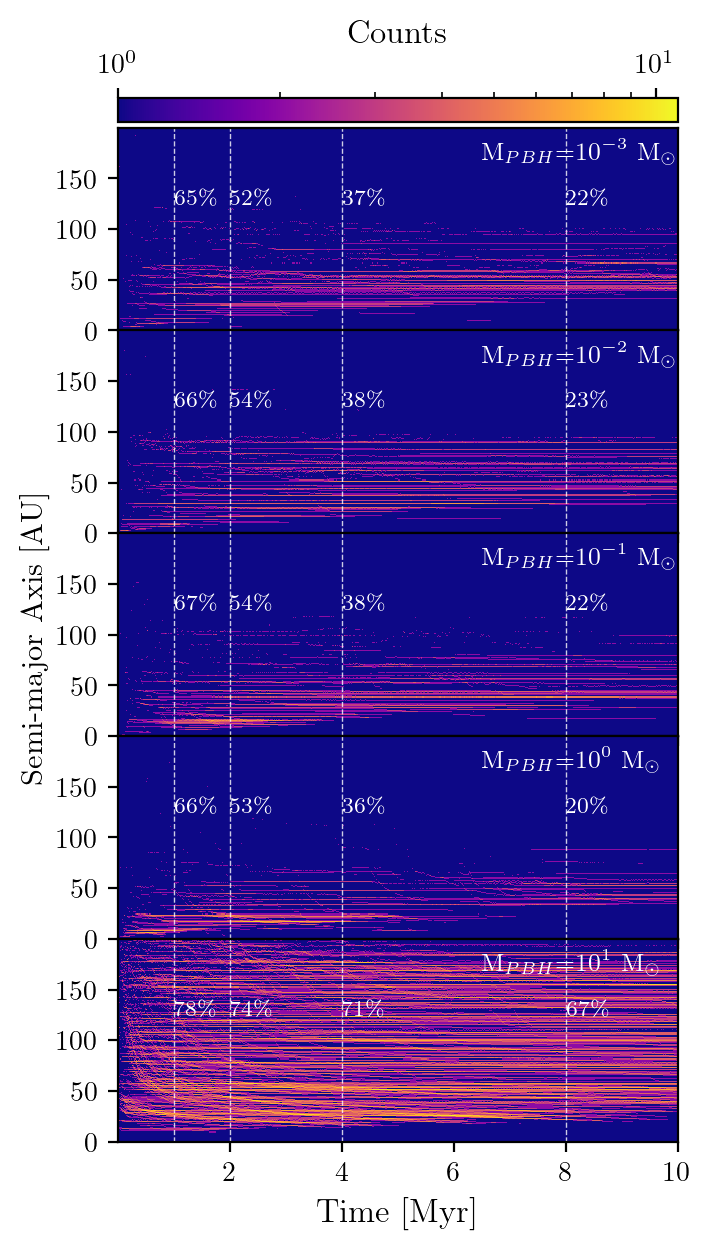

In [52]:
plotobj2.multiple_analysis_time_series_2dhistogram_multipanel(
    metric_name='semi_major_axes',        # ← Keyword arg
    metric_ylabel=r'Semi-major Axis [AU]',  # ← Keyword arg
    time_ylabel=r'Time [Myr]',
    scale=['linear', 'linear', 'log'],
    use_existing_time_series=False,
    metric_range=[0,200],
    metric_bins=200,
    dt_fixed=170,
    survivor_per_at_t=[1e6, 2e6, 4e6, 8e6],
    unit_change=[1e-6, 1, 1],
    ticks=[None, (0, 50, 100, 150), None],
    metric_mask=
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    },  # No mask for orbital_periods
    save_as='semi_major_axis_time_series_histogram_200_masked_dt170_survivors.png',
    fig_size=(3.5,6))

<unknown>:688: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1609: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1816: SyntaxWarning: invalid escape sequence '\%'
<unknown>:688: SyntaxWarning: invalid escape sequence '\o'
<unknown>:1609: SyntaxWarning: invalid escape sequence '\%'
<unknown>:1817: SyntaxWarning: invalid escape sequence '\%'


✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  297 valid points
  Reversed axes: x reversed=True, y reversed=False
  1 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  341 valid points
  Reversed axes: x reversed=True, y reversed=False
  2 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  169 valid points
  Reversed axes: x reversed=True, y reversed=False
  2 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  102 valid points
  Reversed axes: x reversed=True, y reversed=False
  0 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  69 valid points
  Reversed axes: x reversed=True, y reversed=False
  0 outliers detected
  ✓ Finished subplot
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
  73 valid points
  Reversed axes: x reversed=True,

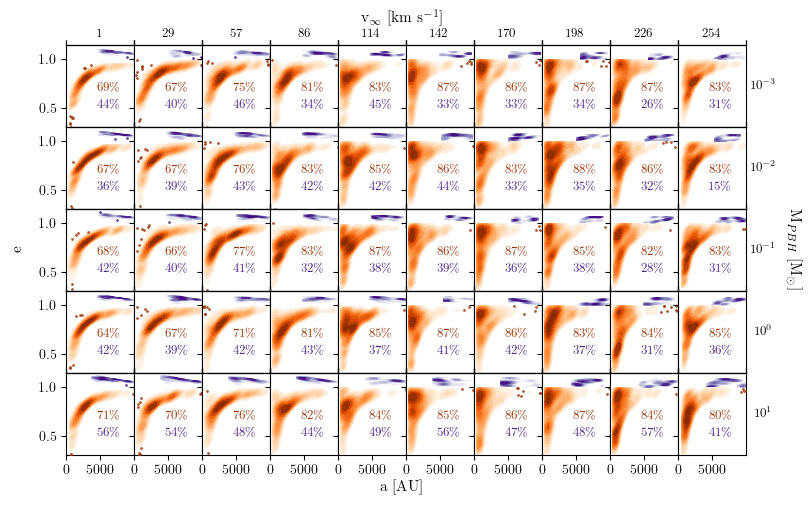

In [44]:
plotobj2.multiple_analysis_metric_gaussian_kde_multipanel(
    metric_xnames=['nocap_a_au', 'cap_a_au'],
    metric_ynames=['nocap_e', 'cap_e'],
    metric_xlabel='a [AU]',
    metric_ylabel='e',
    unit_change=[1, 1, 1],
    analysis_key='All',
    cmaps=['Purples', 'Oranges'],
    scale=['linear', 'linear', 'linear'],
    bw_adjust=0.6,  # ← Bandwidth adjustment
    thresh=0.1,      # ← Outlier threshold (10% of max)
    plot_outliers=True,  # ← Show outliers
    ranges=[[0, 10000], [0.3, 1.15], None],  # ← Set axis limits
    ticks=[[0, 5000], [0.5, 1.0], None],
    save=True,
    cut=0.0,
    add_negative_top_axis=True,
    reverse_axes = [[True, False], [False, False]],  # ← Reverse x-axis for row 0
    percentage_annotations=True,
    fig_size=(8, 5),
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict


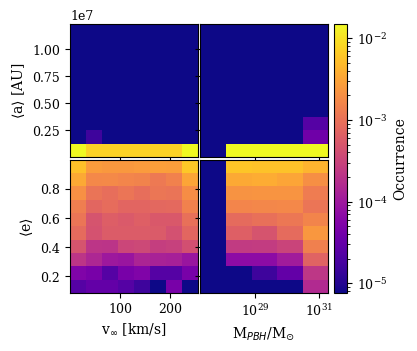

In [41]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$e$\rangle$'],
    voxel_name=['v_inf', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[8, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=None,
    save=True,  # ← Don't save until we confirm it works
    save_as="a_e_averages_histogram.png",
    fig_size=(4, 3.5)
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in analysis_dict


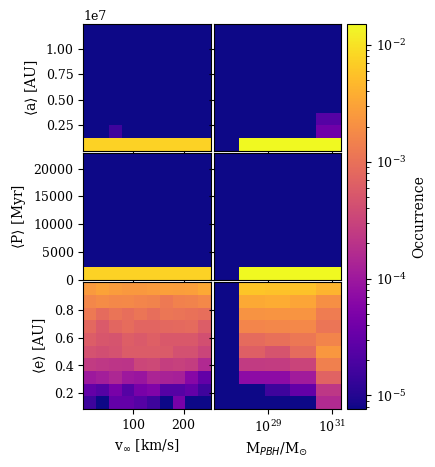

: 

In [ ]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'orbital_periods', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$P$\rangle$ [Myr]', r'$\langle$e$\rangle$ [AU]'],
    voxel_name=['v_inf', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[10, 5],
    metric_bins=10,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1e-6, 1], [1, 1, 1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None, None],
    normalize='total_sample_count',
    normalize_annotation='capture_count',
    annotate_bins=False,
    metric_masks=[
        None,  # No mask for semi_major_axes
        None,  # No mask for orbital_periods
        None
    ],
    save='a_P_e_2dhist.png',  # ← Don't save until we confirm it works
    fig_size=(4, 5)
)

In [ ]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'orbital_periods', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$P$\rangle$ [yr]', r'$\langle$e$\rangle$ [AU]'],
    voxel_name=['v_inf', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[5, 5],
    metric_bins=5,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=[[1e-6, 200], [1e-6, 3000], [1e-6, 1]],  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1/const.M_sun.value,1 ,1]], [[1e-3, 1, 1], [1/const.M_sun.value, 1, 1]], [[1e-3, 1, 1], [1/const.M_sun.value, 1, 1]]],
    v_lim=[None, None, None],
    normalize='total_sample_count',
    normalize_annotation='n_captured',
    annotate_bins=True,
    metric_masks=[
        None,  # No mask for semi_major_axes
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    },  # No mask for orbital_periods
    {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    }
    ],
    save='a_P_e_2dhist_masked_limited.png',  # ← Don't save until we confirm it works
    fig_size=(4, 5)
)

✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in an_entry
✓ Found in analysis_dict
✓ Found in analysis_dict


In [250]:
print(np.round(5.08, 1))

5.1


✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


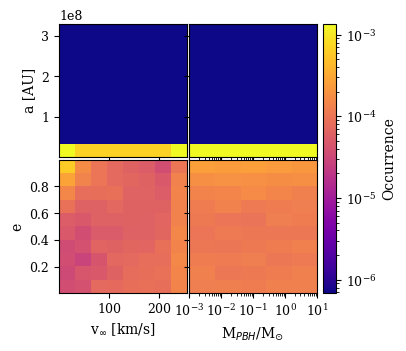

In [96]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['a_au', 'e'],        # ← Keyword arg
    metric_ylabel=[r'a [AU]', r'e'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[8, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=None,
    save=True,  # ← Don't save until we confirm it works
    save_as="initial_a_e_histogram.png",
    fig_size=(4,3.5)
)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


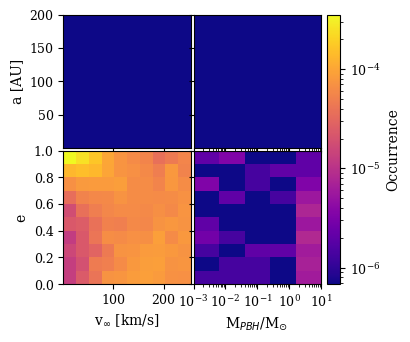

In [97]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['a_au', 'e'],        # ← Keyword arg
    metric_ylabel=[r'a [AU]', r'e'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[10, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=[[1e-6, 200], [0, 1]],  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=[None, 
                      {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    }],
    save=True,  # ← Don't save until we confirm it works
    save_as="initial_a_e_histogram_limited.png",
    fig_size=(4,3.5)
)

In [19]:
# Test on one entry
d = analysis_list[0].get_combined_dictionary()
entry = d['v1']

print("Entry keys:", entry.keys())
print("\nTrying to get a_au:")
result = plotobj4._get_metric_from_sources(entry, 'a_au')
print(f"Result type: {type(result)}")
print(f"Result: {result if not isinstance(result, np.ndarray) else f'array with shape {result.shape}'}")

print("\n\nMC content:")
mc = entry.get('mc')
if mc is not None:
    print(f"mc type: {type(mc)}")
    if hasattr(mc, 'files'):
        print(f"mc.files: {mc.files}")
    elif isinstance(mc, dict):
        print(f"mc.keys(): {mc.keys()}")
    
    # Try direct access
    if hasattr(mc, 'files') and 'a_au' in mc.files:
        print(f"\nDirect mc['a_au']: {mc['a_au'].shape}")
    elif isinstance(mc, dict) and 'a_au' in mc:
        print(f"\nDirect mc['a_au']: {np.shape(mc['a_au'])}")

Entry keys: dict_keys(['v_inf_m_s', 'v_inf_au_yr', 'mC', 'importance_sampling_size', 'sample_count', 'capture_count', 'sampled_capture_count', 'mc', 'rebound', 'sampled_mc', 'termination_counts', 'masks', 'occurrences', 'ej_mask', 'coll_mask'])

Trying to get a_au:
Searching for metric "a_au"...
Result type: <class 'numpy.ndarray'>
Result: array with shape (0,)


MC content:
mc type: <class 'numpy.lib.npyio.NpzFile'>
mc.files: ['v_inf', 'n_captured', 'sigma_MC_m2', 'sigma_MC_areaB', 'a_au', 'e', 'cap_lambda', 'cap_beta', 'cap_b', 'cap_phi', 'epsilon', 'sample_number', 'execution_time']

Direct mc['a_au']: (200,)


Axis 0: Collected 16287 data points for 'orbital_periods'
Axis 1: Collected 16287 data points for 'orbital_periods'


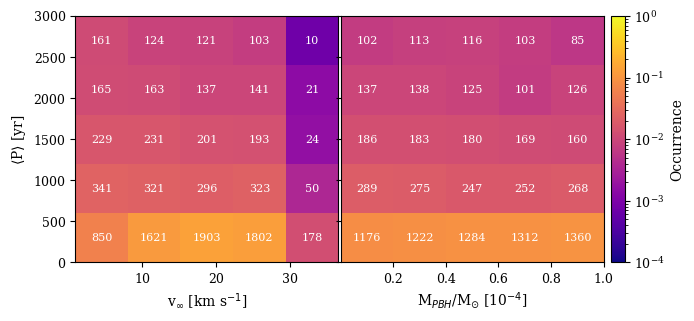

In [143]:
plotobj4.multiple_analysis_voxel_2dhistogram(
    metric_name='orbital_periods',        # ← Keyword arg
    metric_ylabel=r'$\langle$P$\rangle$ [yr]', # ← Keyword arg
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_{\infty}$ [km s$^{-1}$]', r'M$_{PBH}$/M$_{\odot}$ [10$^{-4}$]'],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=['linear', 'linear', 'log'],
    v_key='All',
    global_ylim=False,
    voxel_bins=5,
    metric_bins=5,
    voxel_range=None,
    metric_range=[0, 3000],
    unit_change=[[1e-3, 1, 1], [1e4, 1, 1]],
    v_lim=[1e-4, 1],
    normalize='sample_count',
    annotate_bins=True,
    save=True
)